# W6 deck figures: the premise, the three branches, and why covariates do not sharpen the siting

Ten results. All but two are national; the siting figure and the NDVI decomposition are drawn on one
region — the Klamath Mountains / California High North Coast Range, 198 res-5 hexes.

1. **The season that starts the most fires is not the season that burns.** Starts peak in spring,
   acres in late June — the count-vs-consequence gap the project's acre-weighting exists to handle.
2. **Cause is regional, and regions commit.** 50 of 105 ecoregions are below 20% natural and 28
   above 80%, so the national 58.9/22.6 split describes almost no region in particular.
3. **A region's own history forecasts its cause mix.** 73% of a held-out season's composition lands
   on the right cause, against 42% for the national average and 52% for an even split.
4. **A few years of rolling average is enough.** One prior season to three is worth 5.3 points;
   every window from three up sits within 1.4 points of the best.
5. **The same holds one level deeper.** Within Human, history names the leading sub-cause 54% of the
   time out of 11 candidates, against a 9% chance floor and 16% for the national human mix.
6. **A learned model does not beat that floor** — 36% on region character, and 47.5% even when
   handed the trailing history the floor averages.
7. **Nearly a fifth of burned acres carry no specific cause, and that gap is forecastable.**
   Acre-weighted MAE 0.167 against the global mean's 0.240; the triage list ranks region-seasons by
   predicted unattributed acres.
8. **Ignition likelihood is rankable.** The persistence baseline (a hex's own natural + human
   ignition history, k=7, from seasons strictly before the target) orders hexes well enough that 30%
   of a held-out season's starts fall under 6% of the ground.
9. **Fuel-state covariates do not improve that ranking**, because their variation is between places
   rather than between years — and place is what persistence already encodes.
10. **Burned area cannot substitute for ignition as the ranking quantity** on the natural branch.
    Acres concentrate almost entirely in a top decile the baseline misses by 270x. On the human
    branch the same miss is 12.3x, which is why the two branches support different products.

Figures are rendered by [`../src/w6_visuals.py`](../src/w6_visuals.py).

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image

sys.path.insert(0, "../src")
import w6_visuals as wv
from config import ProjectConfig

cfg = ProjectConfig()
DATA = cfg.data
IMG = Path("../img")
IMG.mkdir(exist_ok=True)

ndvi = pd.read_parquet(DATA / "hex_season_ndvi.parquet")
grid = pd.read_parquet(DATA / "hex_grid_res5.parquet")
print(f"{len(ndvi):,} hex-seasons | {ndvi['hex_id'].nunique():,} hexes "
      f"| {ndvi['season_year'].min()}-{ndvi['season_year'].max()} "
      f"| seasons: {sorted(ndvi['season'].unique())}")

55,923 hex-seasons | 2,663 hexes | 2000-2020 | seasons: ['JJA']


## The year: where fires start, and where acres burn

National, all 2.27M cleaned fires, 1992–2020. Weekly starts and acres, divided by the 29 years of
record so the reading is a typical week rather than a total.

Neither y-axis is drawn. Two series on two scales in one frame invites reading the point where the
dashed line crosses the filled area as meaningful; it is not, since it falls wherever the two
arbitrary scalings intersect. What remains comparable is the shape of each curve along a shared
calendar — when each one peaks — and the magnitudes are stated exactly in the callouts.

               n_years: 29
  spring_starts_peak_week: 14
    spring_starts_mean: 2458.137931034483
  spring_starts_median: 2342.0
            july4_week: 26
     july4_starts_mean: 2817.068965517242
       acres_peak_week: 24
       acres_peak_mean: 526416.2097175863
     acres_peak_median: 237330.77
        acres_peak_max: 4381306.54
   acres_peak_max_year: 2015
              out_path: ../img/w6_seasonality.png


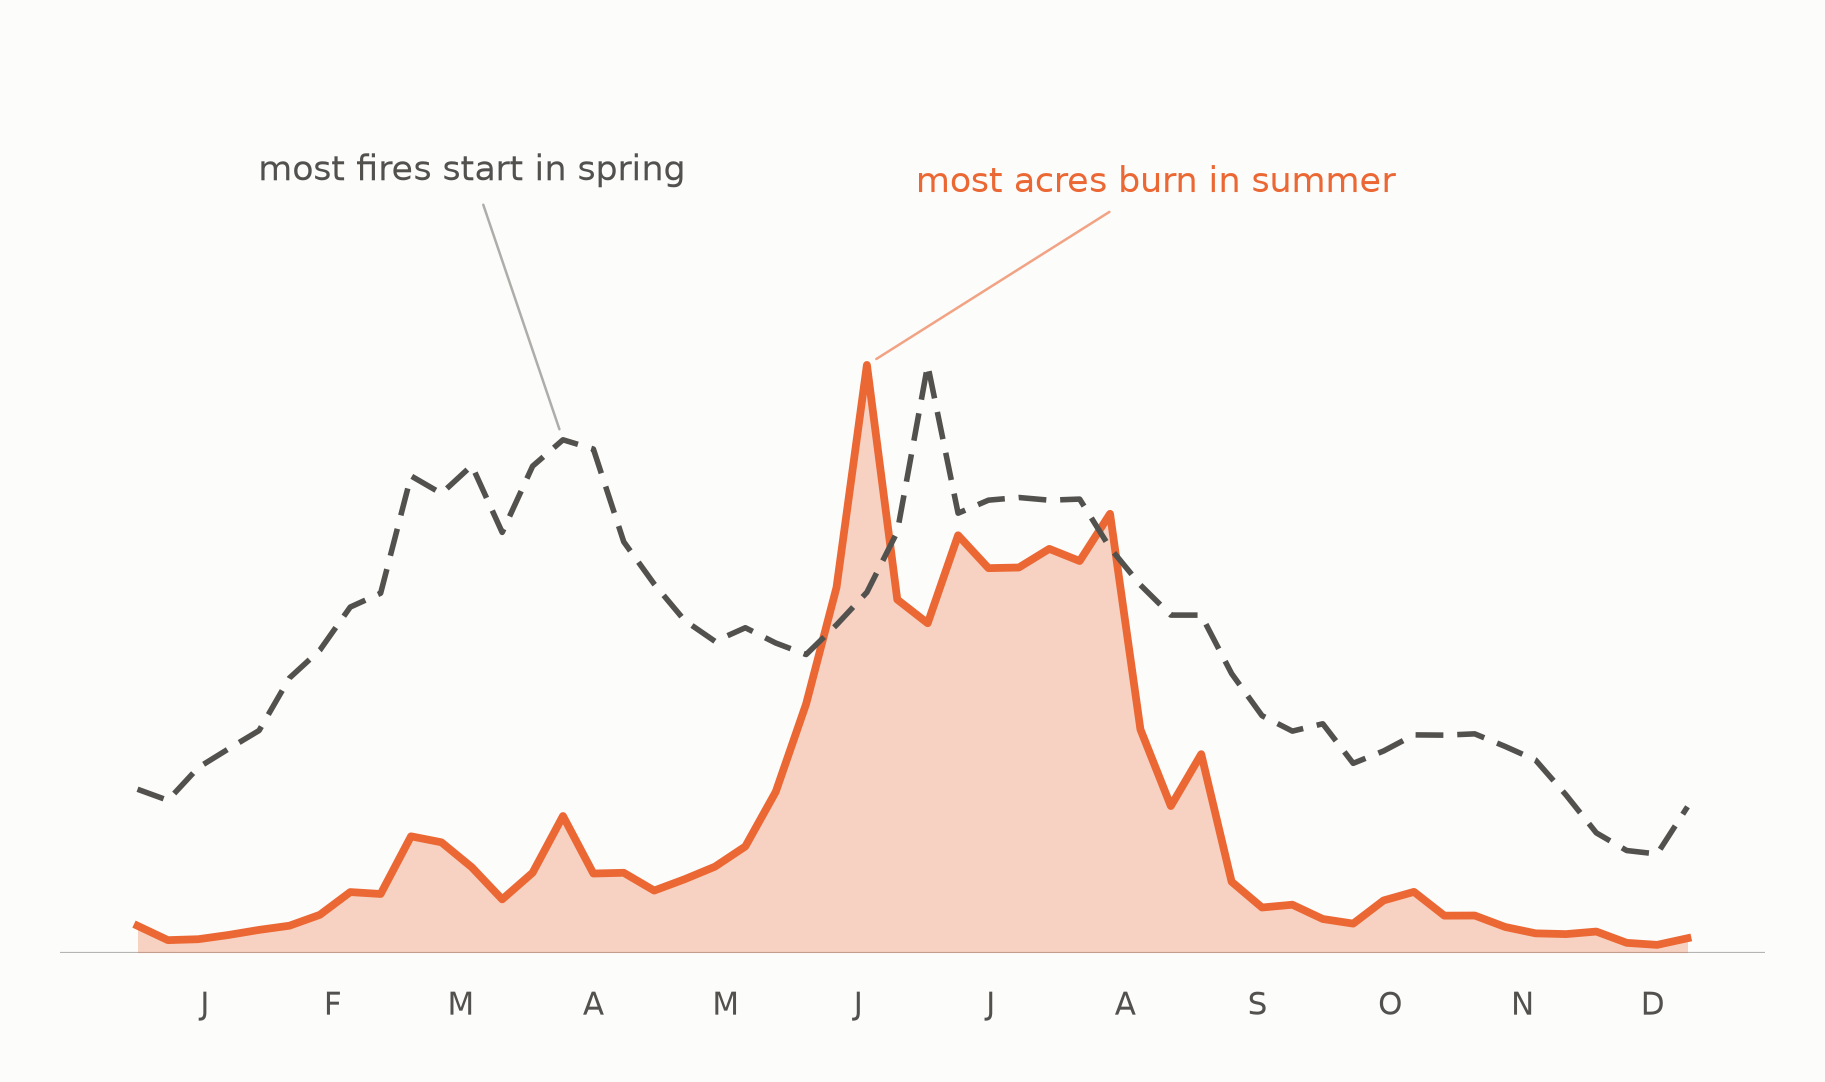

In [2]:
fires = pd.read_parquet(
    DATA / "fires_clean.parquet",
    columns=["FIRE_SIZE", "DISCOVERY_DOY", "NWCG_CAUSE_CLASSIFICATION", "FIRE_YEAR"])

seas = wv.plot_seasonality(fires, IMG / "w6_seasonality.png")
for k, v in seas.items():
    print(f"  {k:>20}: {v}")

Image(filename=seas["out_path"], width=980)

**The season that starts the most fires is not the season that burns.** Starts peak in spring and
acres in late June. Counting ignitions and counting consequences give different answers about when
the year is dangerous, which is why cause composition is reported acre-weighted throughout this
project.

| season | starts | acres |
| --- | --- | --- |
| DJF | 15.4% | 4.4% |
| MAM | 33.5% | 17.5% |
| JJA | 33.0% | **68.1%** |
| SON | 18.0% | 10.0% |

MAM and JJA start nearly the same number of fires and differ by **3.9x** in acres burned.

### How the plotted points are derived

Each fire is assigned a week-of-year from `DISCOVERY_DOY` as `(DOY - 1) // 7`, clipped to 0–51 so
the ragged 53rd week folds into the last. For each of the 52 slots the series are then:

- **starts** — count of fires discovered in that slot across 1992–2020, divided by 29 years
- **acres** — sum of `FIRE_SIZE` in that slot across the same span, divided by 29

So a plotted point is the **mean across 29 years for one week-of-year slot**, not a median week and
not a summer average.

**Why no magnitudes appear on the figure.** For acres that mean is not a typical value. In the peak
slot (week 24) the mean is **526k** against a median of **237k** — a 2.2x gap produced by a single
year, 2015, which burned **4.38M** acres in that one week. Printing 526k beside the word "typical"
would assert precisely what this project's tail analysis disproves (see the concentration curve
below: the top 1% of burning cells hold 55% of natural acres). Starts are better behaved — mean
2,458 against median 2,342 — but a magnitude on one curve and not the other invites the
cross-series comparison the missing axes exist to prevent. The figure claims *when*, and only when.

The numbers above are returned by `plot_seasonality` rather than printed on the image, so they can
be quoted with the caveat attached.

**Why weekly rather than monthly.** Monthly bars are smoother and drop the July 4 spike, but the
aggregation merges that spike into July and lifts July (10,141 starts) above March (9,726) —
inverting the claim, so that July rather than spring becomes the starts maximum. At weekly grain the
spring hump is the genuine seasonal peak and the July 4 week (2,817) is a separable one-week event.
For the same reason the spring peak is located *within* spring (weeks 8–22) rather than by taking
the curve's global maximum, which is that July 4 week.

**Scope.** All causes combined, national. The Human/Natural split — starts peaking 15 weeks apart —
is a later beat; four curves here would lose the one comparison this figure exists to make.
Regional contrast is the subject of the Level III notebooks.

## Cause is regional

All 105 Level III ecoregions shaded by the share of their attributed acres that is natural, pooled
across 1992–2020. Alaska is drawn inset in its own equal-area CRS: it is 20 of the 105 regions and
the most natural-dominated ground in the record, so dropping it would remove one end of the very
contrast the map is making.

**The denominator is attributed acres only** — Human + Natural, excluding the Unknown mass. On a
total-acres denominator a region with poor cause reporting drifts toward the middle of the scale for
a records reason rather than a fire reason, which would make this partly a map of attribution
quality. That is a different branch and a later beat; `region_cause_dominance` returns
`unknown_share` alongside so the caveat stays quotable.

               n_regions: 105
         human_dominated: 50
       natural_dominated: 28
                   mixed: 27
    median_natural_share: 0.269
                out_path: ../img/w6_cause_map.png


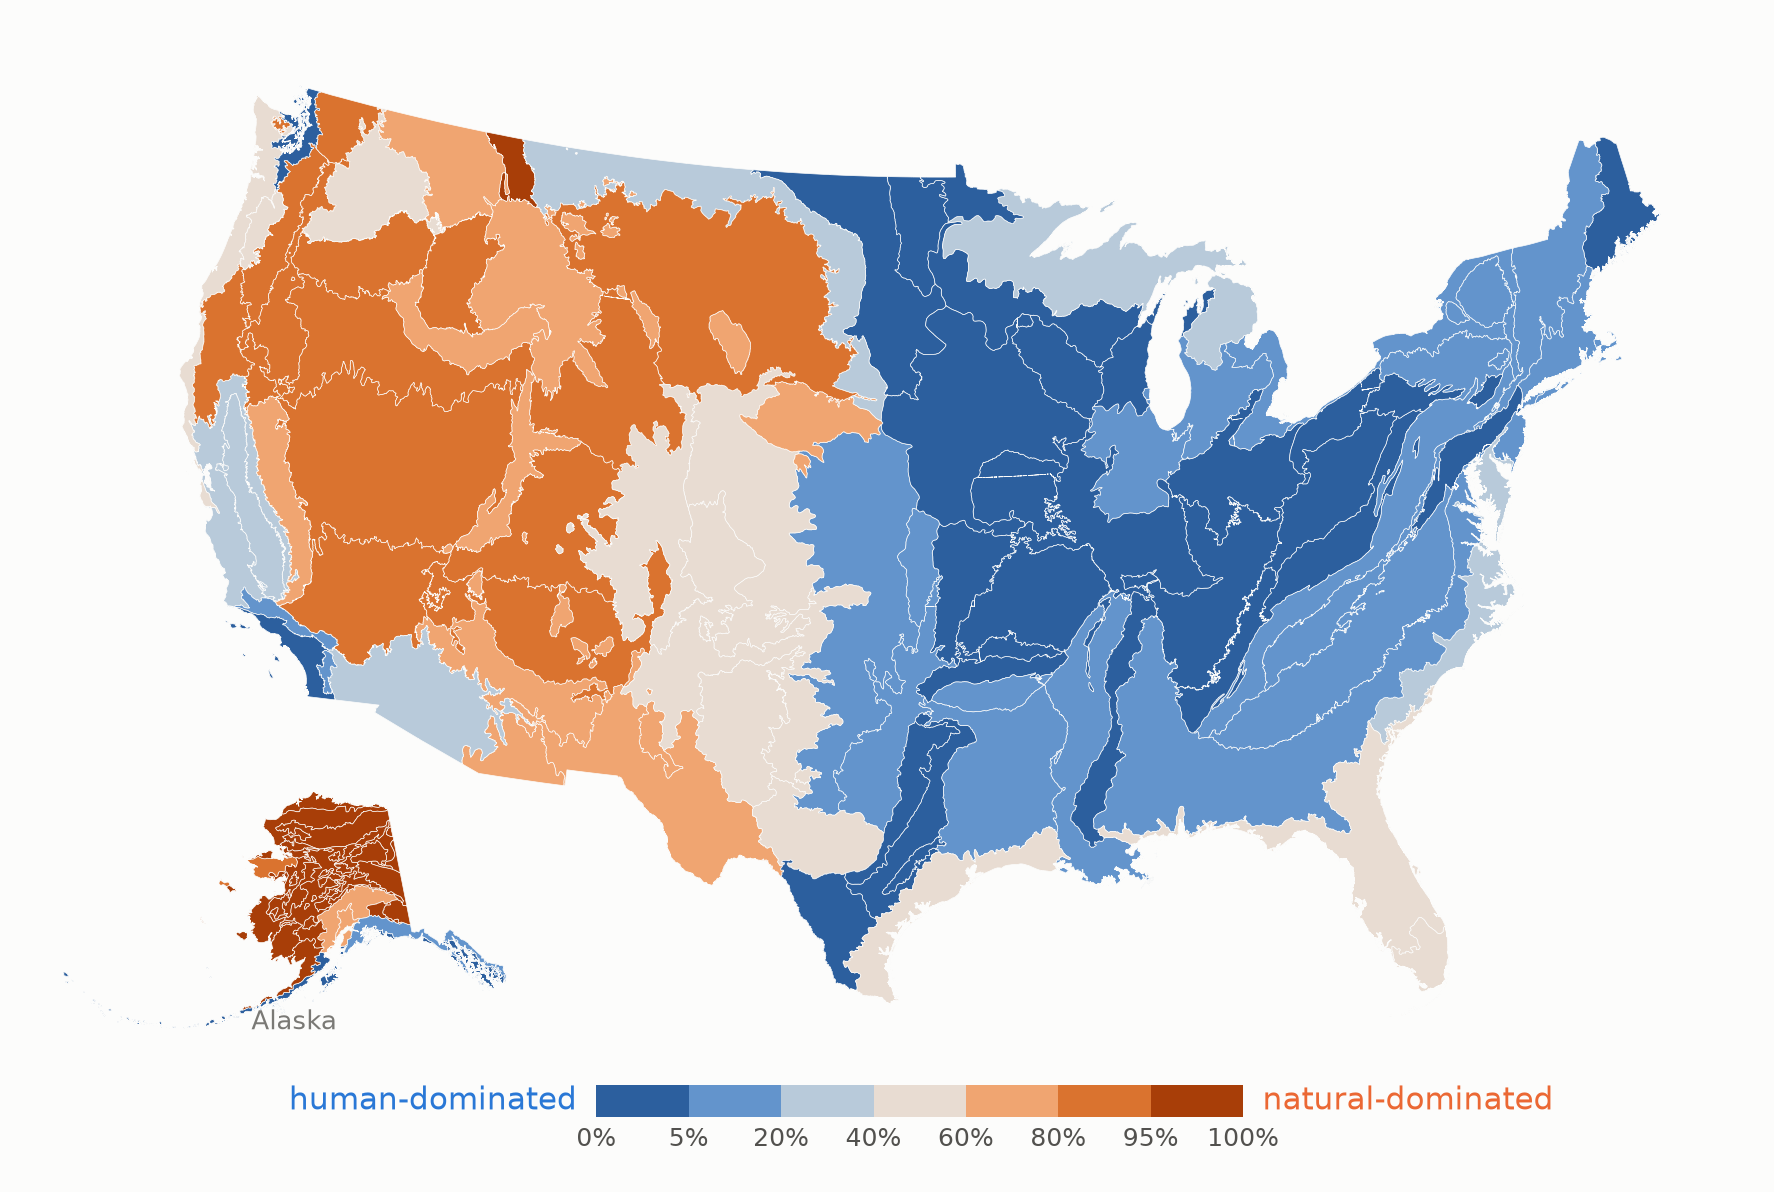

In [3]:
from panel import RegionSeasonPanel

rsp = RegionSeasonPanel.load(cfg)

cause = wv.plot_cause_map(rsp, IMG / "w6_cause_map.png", cfg=cfg)
for k, v in cause.items():
    print(f"  {k:>22}: {v:.3f}" if isinstance(v, float) else f"  {k:>22}: {v}")

Image(filename=cause["out_path"], width=980)

**Regions commit to one cause or the other; the national average describes almost none of them.**

Nationally the split is 58.9% natural, 22.6% human, 18.5% unknown. Across regions the distribution
is bimodal rather than centred on that average: **50 of 105 regions fall below 20% natural and 28
above 80%**, leaving only 27 in between. The median region is 26.9% natural — well below the
national figure, because the national number is dominated by a small number of very large
natural-burning regions.

The geography is a West/East split at roughly the 100th meridian, with Alaska almost entirely
natural. Two CONUS regions of comparable size sit at opposite ends:

| region | total acres | natural share |
| --- | --- | --- |
| Canadian Rockies | 1,251,982 | **98.9%** |
| Central Appalachians | 1,621,768 | **0.5%** |

That is what licenses a per-region prevention/mitigation split rather than one national posture: a
plan built for the Central Appalachians targets human ignition almost exclusively, and the same plan
in the Canadian Rockies would address 1% of what burns.

**Why a stepped scale rather than a continuous ramp.** A smooth ramp invites reading a gradient
across the middle of the range that the distribution does not contain. The bins are cut at 5/20/40/
60/80/95% so the two committed ends carry most of the visual range and the sparse middle reads as
sparse.

**Scope.** Pooled across all seasons and all years, 1992–2020. Season-by-season composition is the
Tier 1 target and is treated in [`06_analysis.ipynb`](06_analysis.ipynb); this figure is the
time-averaged picture that motivates modelling it per region at all.

## Is a region's cause mix stable enough to forecast?

Three predictors of a region-season's burned-acre composition across Human / Natural / Unknown,
scored on held-out seasons (season-year ≥ 2010, forward-chaining, 3,949 region-seasons):

- **the national average mix** — the record's overall composition, applied to every region
- **an even split** — an uninformed 1/3 on each class
- **the region's own history** — its own k=7 trailing mean, using only strictly earlier seasons

The tiles are ordered worst to best, so the sequence builds to the winning number rather than opening
on it, and the two uninformed baselines sit adjacent — which is where the sharpest comparison is.

**The tiles show `1 - TVD`, not TVD.** Total Variation Distance is `½·Σ|predicted − actual|` across
the three shares: 0 is a perfect match, 1 is disjoint, and *lower is better* — which reads backwards
on a tile whose largest number should be its best result. The inverse is not a cosmetic flip: on a
simplex `1 - TVD` is exactly the overlap between the two compositions (the sum of elementwise
minima), so "share of the composition placed on the right cause" is a literal reading. The cell
below asserts that identity rather than taking it on trust.

**It is an accuracy derived from the magnitude of the error, not a hit rate.** Nothing is scored
right or wrong; the absolute errors on the three shares are summed, halved, and subtracted from 1.
It belongs in the same family as a mean absolute error — there is no "of the time" to attach to it.

             n_cells: 3949
          test_start: 2010
                   k: 7
     history_correct: 0.7337
    national_correct: 0.4204
       naive_correct: 0.5152
         history_tvd: 0.2663
        national_tvd: 0.5796
           naive_tvd: 0.4848
                best: history
            out_path: ../img/w6_tier1_tiles.png

1 - TVD == composition overlap: verified


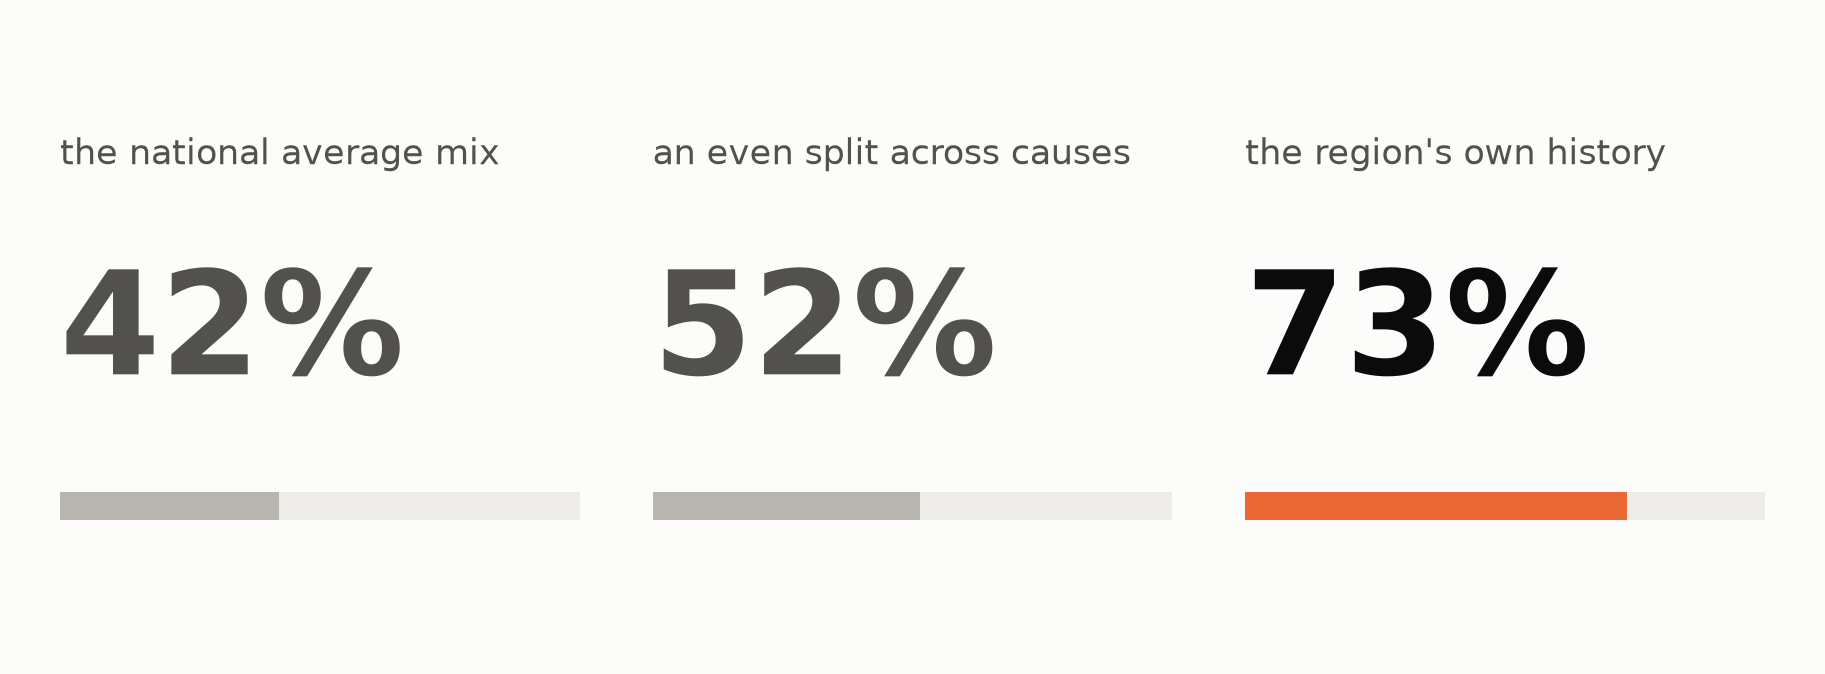

In [4]:
import numpy as np

tiles = wv.plot_tier1_tiles(rsp, IMG / "w6_tier1_tiles.png", cfg=cfg)
for k, v in tiles.items():
    print(f"  {k:>18}: {v:.4f}" if isinstance(v, float) else f"  {k:>18}: {v}")

# Assert the identity the tile labels rely on: on a simplex, 1 - TVD is the
# overlap between the two compositions, so "share placed on the right cause"
# is literal rather than a gloss.
sc = wv.tier1_baseline_scores(rsp, cfg=cfg)
assert np.isclose(sc.loc["history", "correct"], 1 - sc.loc["history", "tvd"])
print("\n1 - TVD == composition overlap: verified")

Image(filename=tiles["out_path"], width=980)

**Yes — but the stability is relative to the alternatives, not absolute.**

A region's own history places **73%** of its next-season burned-acre composition on the right cause.
The national average mix places **42%**, and an uninformed even split **52%** — so applying the
national composition to a specific region is *worse than guessing uniformly*. That is the bimodality
of the cause map showing up as forecast error: the national figure is dominated by a handful of very
large natural-burning regions and describes almost no region in particular.

Three things are true at once, and the deck keeps them separate:

1. **Regions move year to year.** The median region's natural share has a year-to-year SD of 0.181,
   and some swing the full range. "Flat lines" would be the wrong claim.
2. **They move around their own persistent level**, not the national one — which is why history
   halves the error against the national average.
3. **The mix is forecastable; the amount is not.** [`06_analysis.ipynb`](06_analysis.ipynb) finds the
   *level* roughly 9x off in big seasons while the *composition* scores here. The product ranks
   causes and does not promise acres.

**Scope.** Acre-weighted, so a 3M-acre region-season counts for more than a 200-acre one, matching a
product that ranks by acres. Every prediction uses only strictly earlier seasons.

## How many past seasons should the average cover?

The same acre-weighted score as the tiles above, swept across trailing-window lengths. Calls
`trailing.TrailingMean` rather than reimplementing the window, so this figure and
[`06_analysis.ipynb`](06_analysis.ipynb) cannot drift apart.

      n     tvd  tvd_unweighted  correct
k                                       
1  3949  0.3305          0.3138   0.6695
2  3949  0.2983          0.2844   0.7017
3  3949  0.2780          0.2775   0.7220
4  3949  0.2799          0.2736   0.7201
5  3949  0.2737          0.2703   0.7263
6  3949  0.2673          0.2694   0.7327
7  3949  0.2663          0.2678   0.7337
8  3949  0.2677          0.2671   0.7323

                best_k: 7
          best_correct: 0.7337
              best_tvd: 0.2663
            k1_correct: 0.6695
       gain_k1_to_best: 0.0641
       gain_k3_to_best: 0.0117
          plateau_from: 3
        plateau_spread: 0.0136
    monotonic_acre_wtd: False
               n_cells: 3949
              out_path: ../img/w6_k_sweep.png


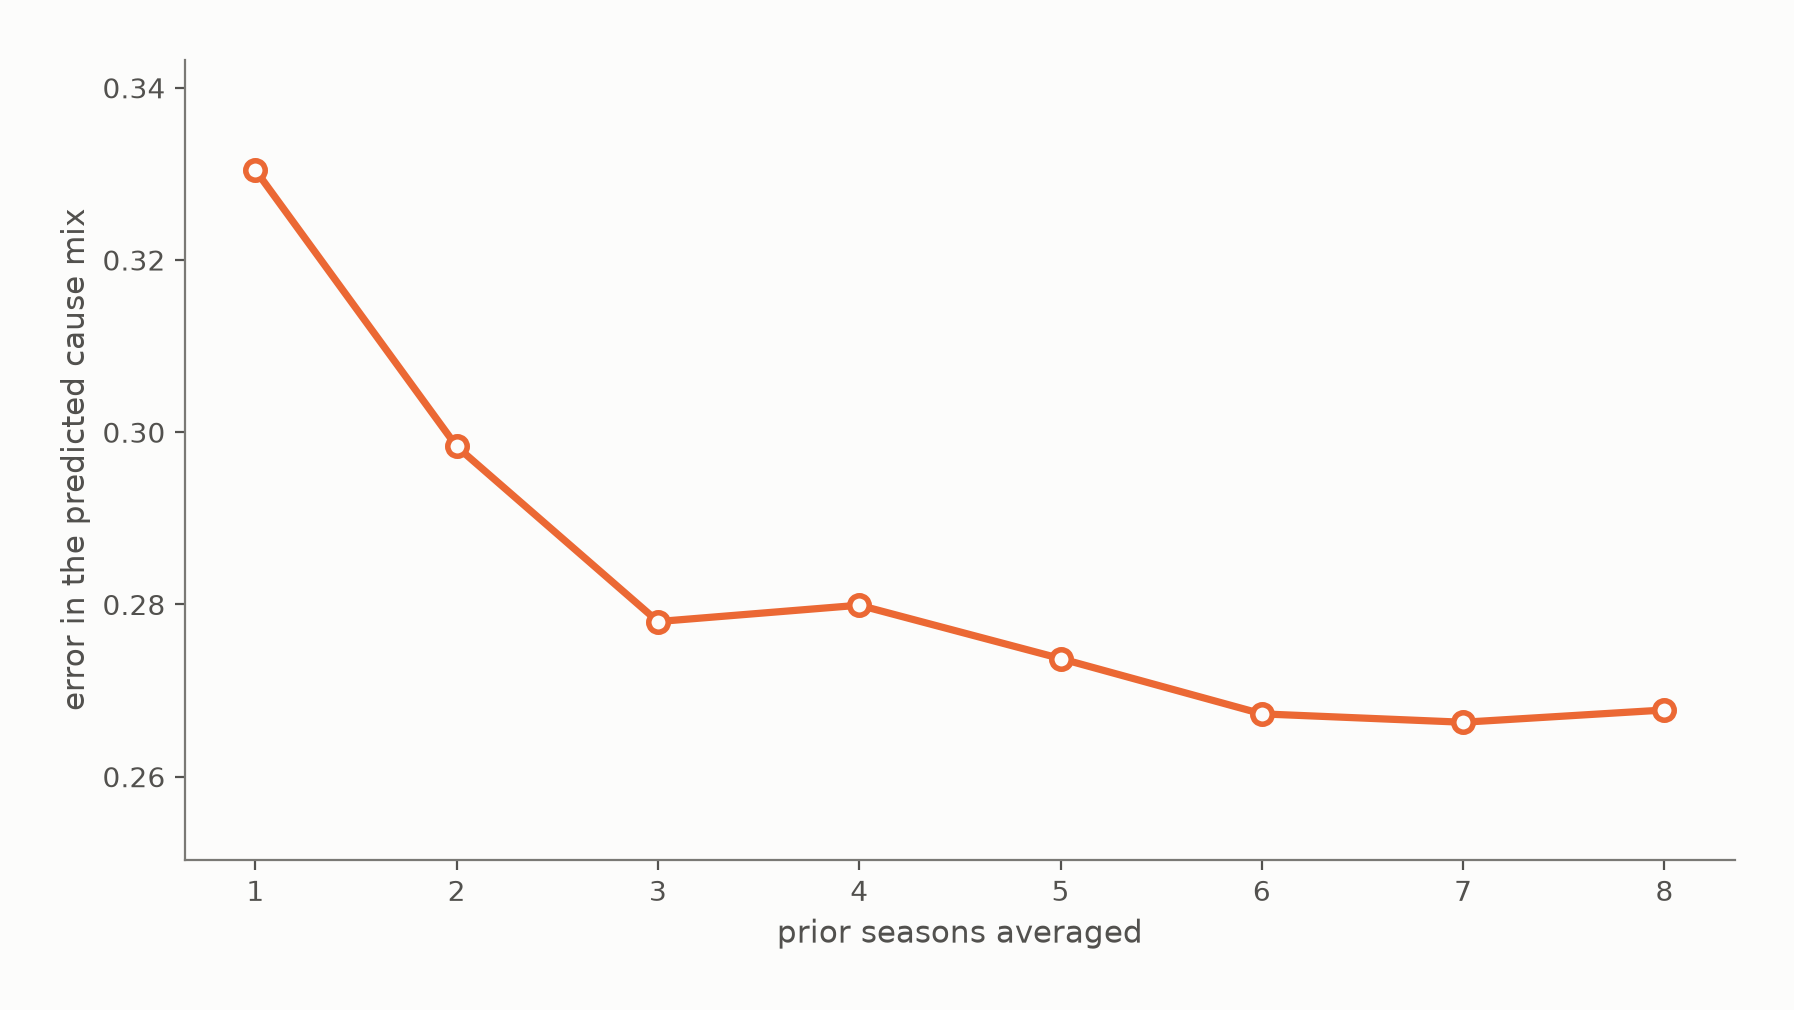

In [5]:
sweep = wv.tier1_k_sweep(rsp, cfg=cfg)
print(sweep.round(4).to_string())

ks = wv.plot_k_sweep(rsp, IMG / "w6_k_sweep.png", cfg=cfg)
print()
for k, v in ks.items():
    print(f"  {k:>20}: {v:.4f}" if isinstance(v, float) else f"  {k:>20}: {v}")

Image(filename=ks["out_path"], width=900)

**The gain is front-loaded, then the window stops mattering.**

Error falls sharply from one prior season (TVD 0.331) to three (0.278) — a **5.3 point** drop — and
then flattens. Every window from three up sits within **1.4 points** of the best. k=7 is the
acre-weighted optimum but beats k=3 by only 1.2 points, so it is a cheap choice rather than a
load-bearing one.

The reading is not "more history is always better." It is that **one year is not enough, and beyond
about three the choice is nearly free** — which is what [`06_analysis.ipynb`](06_analysis.ipynb)
settles as the static-vs-dynamic question: a single prior year is mostly tail noise, since one
megafire swings it and an average washes it out. `t-4` (a true year-ago step) scores 0.331
acre-weighted TVD against k=7's 0.266.

**The figure plots TVD directly rather than `1 - TVD`.** The beat-3 tiles invert the measure because
a stat tile whose largest number is its worst result reads backwards; a curve has no such problem, a
falling line reads as improvement on its own. Plotting the raw score keeps the axis identical to the
values notebook 06 reports, with no derived quantity to explain.

**The acre-weighted curve is not monotonic, and the figure does not smooth that away.** It rises at
k=4 (+0.0019 TVD) and again at k=8 (+0.0014); only the *unweighted* sweep falls monotonically.
Nothing else is drawn — no marked winner, no shaded plateau, no annotation — because the flattening
is legible in the curve's own shape, and an earlier draft's shaded band restated the slide headline
inside the figure.

**Consequence for the model.** A learned *temporal* model has little to exploit here. Any lift has
to come cross-sectionally — from region and season features, or external covariates — which is what
the hex-grain covariate ladders test later in this notebook.

## The same question, one level deeper: which human cause leads?

Tier 1 splits a region-season's acres across Human / Natural / Unknown. The Human branch then asks
which of **11** sub-causes leads those human acres — Debris and open burning, Arson, Equipment and
vehicle use, Recreation and ceremony, Powerline, Smoking, Railroad, Fireworks, Firearms, Misuse of
fire by a minor, Other.

Same three predictors, same forward-chaining split, same tile form as above — deliberately, since a
reader who learned the encoding two figures ago should not have to learn a second one.

**Scored as top-1, not `1 - TVD`.** Across 11 classes the mass concentrates in a few, so an overlap
score stays comfortable without the model ever naming the right leader: the national mix scores
0.643 TVD while getting the leader right only 16% of the time. A planner asking *which cause do I
target* is asking a top-1 question, so that is what the tiles report. Weights are `human_total_ac`,
matching [`08_human_cause.ipynb`](08_human_cause.ipynb).

             n_cells: 3850
           n_classes: 11
                   k: 7
       leading_cause: Arson/incendiarism
        history_top1: 0.5405
       national_top1: 0.1640
         chance_top1: 0.0909
         history_tvd: 0.4887
        national_tvd: 0.6431
                best: history
            out_path: ../img/w6_human_tiles.png


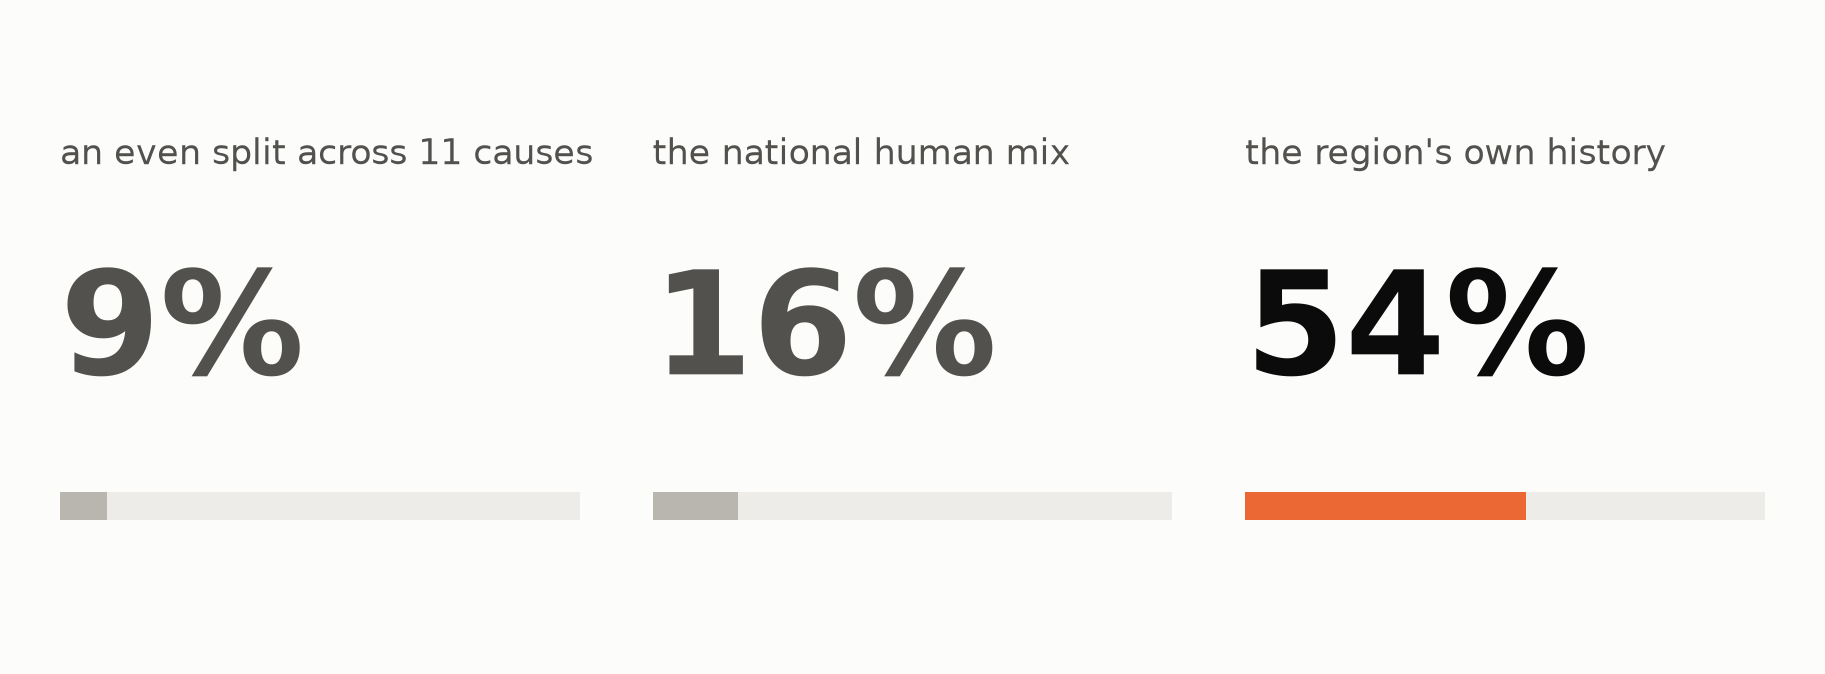

In [6]:
hum = wv.plot_human_tiles(rsp, IMG / "w6_human_tiles.png", cfg=cfg)
for k, v in hum.items():
    print(f"  {k:>18}: {v:.4f}" if isinstance(v, float) else f"  {k:>18}: {v}")

Image(filename=hum["out_path"], width=980)

**History names the leading human cause more often than not — 54% against a 9% chance floor.**

The ladder is steeper than Tier 1's because the problem is harder. An even split across 11 causes
would be right 9% of the time. The national human mix does better at 16%, but only because it always
answers the same thing — **Arson/incendiarism**, the acre-weighted leader across the training years,
which is genuinely the leading cause in some regions and wrong in most. A region's own history
reaches **54%**, a six-fold lift over chance.

That is the beat's whole claim: *more often than not*, on an 11-way problem, from history alone.

**Why the national mix scores so poorly here.** It is a single fixed answer applied to 105 regions,
so it can only be right where the national leader happens to be the local one. This is the same
failure as beat 3's national-average tile, sharpened: at Tier 1 a fixed answer still overlaps a lot
of the truth, but at top-1 on 11 classes it either names the right cause or it does not.

**Caveat carried forward.** These are the persistence *floors*. A learned rung was added to this
branch and lost — TVD 0.489 → 0.588, top-1 54% → 36% — which is the next beat.

**Scope.** 3,850 held-out region-seasons, weights `human_total_ac`. Cells with no human acres and
cells with no prior history are unscored. The training-years prior is computed on `season_year <
2010` only, so the national tile carries no information from the scored seasons.

## Does a learned model beat that floor?

Three rungs on the same held-out cells, from [`08_human_cause.ipynb`](08_human_cause.ipynb):

1. **the region's own history** — the k=7 trailing human mix, the floor from the tiles above
2. **gradient boosting on region character** — the `f_*` fingerprint features plus season: how much
   the cell burns, its long-run Human/Natural/Unknown split, its typical fire size. The model never
   sees the cell's own human sub-cause past.
3. **gradient boosting, given that history** — the same model, additionally handed the 11 trailing
   human-mix columns as features. That is the *exact quantity* rung 1 averages.

`human_rung_scores` refits all three by calling the same `models.SimplexRegressor` and
`trailing.TrailingMean` the notebook uses, so the figure cannot drift from the result it reports.
It fits 22 gradient-boosted regressors and takes a couple of minutes.

**Acre weights go into the fit, not just the scoring.** A first reproduction that omitted
`sample_weight` scored the learned rungs at 0.570 / 0.546 instead of 0.588 / 0.554 — close enough to
look right and wrong enough to matter. Unweighted, the model spends its capacity on cells carrying
almost no acres.

                                               label     tvd    top1
key                                                                 
floor                       the region's own history  0.4887  0.5405
coarse         gradient boosting on region character  0.5877  0.3566
history_aware  gradient boosting, given that history  0.5536  0.4748

held-out cells: 3,846   train: 5,312
  0.540  beats floor  the region's own history
  0.475  below floor  gradient boosting, given that history
  0.357  below floor  gradient boosting on region character


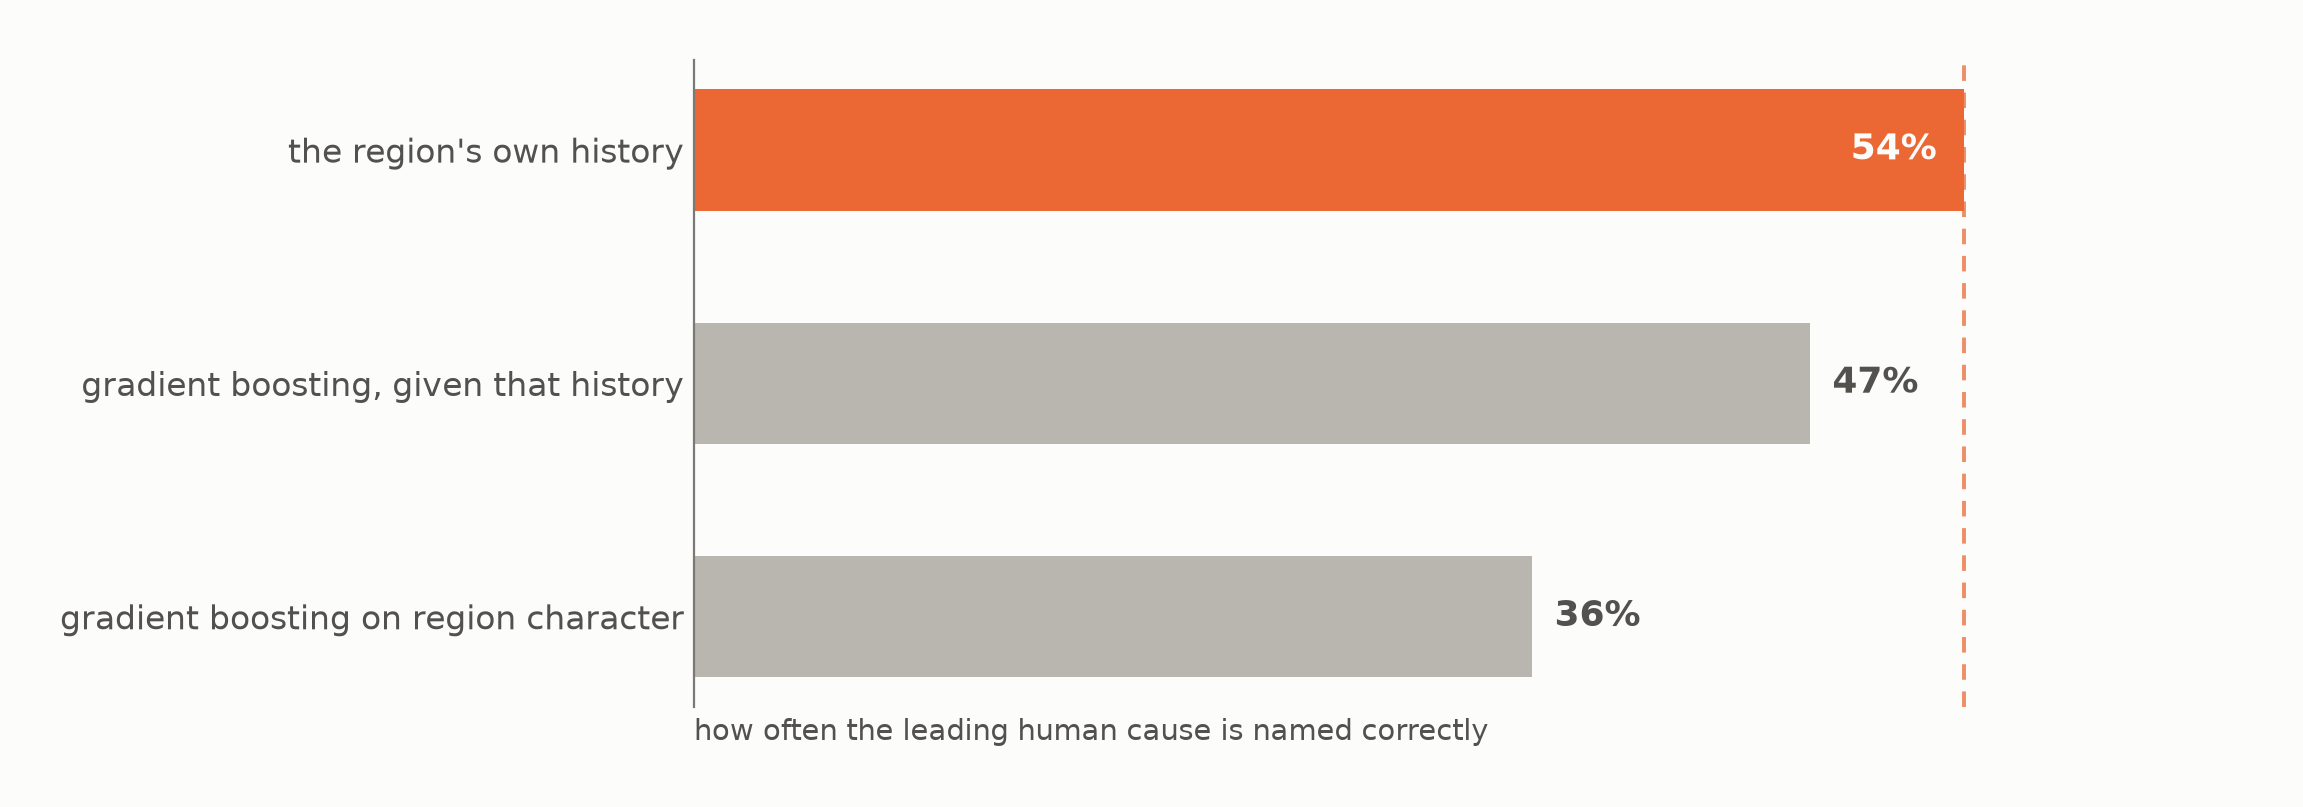

In [7]:
rungs = wv.human_rung_scores(rsp, cfg=cfg)      # ~2 min: fits 22 GBMs
print(rungs.round(4).to_string())
print(f"\nheld-out cells: {rungs.attrs['n_test']:,}   train: {rungs.attrs['n_train']:,}")

# sort=True -> bars descend by value (54, 47, 36) rather than by the order the
# rungs were tried. The floor still wins, and now it visibly sits on top.
lad = wv.plot_ablation_ladder(
    rungs["label"], rungs["top1"], IMG / "w6_human_ladder.png",
    xlabel="how often the leading human cause is named correctly",
    sort=True)
for lbl, val, ok in zip(lad["labels"], lad["values"], lad["beats_floor"]):
    print(f"  {val:.3f}  {'beats floor' if ok else 'below floor'}  {lbl}")

Image(filename=lad["out_path"], width=900)

**Neither learned rung clears the floor, and the second one is the finding.**

| rung | TVD | top-1 |
| --- | --- | --- |
| the region's own history (k=7 mean) | **0.489** | **54.1%** |
| gradient boosting on region character | 0.588 | 35.7% |
| gradient boosting, given that history | 0.554 | 47.5% |

**Rung 2 fails for a legible reason.** A region's coarse character — how much it burns, its long-run
Human/Natural/Unknown split — does not recover its *within-Human* sub-cause mix. Knowing a region is
a big natural-burning place says nothing about whether its human fires are debris burns or arson.
The fingerprint is not merely uninformative here; at 36% against a 54% floor it is actively
misleading.

**Rung 3 is the one worth showing.** Hand the model the trailing human mix itself — the exact
quantity the floor averages — and it recovers most of the loss but still lands **7 points short of
simply taking that feature's mean**. The information was in the feature set; the model could not use
it as well as arithmetic did. With 3,846 training cells and 11 correlated targets there is not
enough signal to learn a better function of the history than its average.

That is what makes this a credible null rather than a weak baseline. The comparison is not
"persistence versus a model that never saw the data" — it is persistence versus a model handed the
same information and given every chance to improve on it.

**Scope.** Same held-out cells as the tiles above, acre-weighted, forward-chaining. The learned rungs
were tried once with the project's standard `SimplexRegressor` settings and not tuned further; a
hyperparameter search might close part of the 7-point gap, and nothing here rules that out.

## Where the record itself is the weak link

The third Tier-1 class is not a forecast target in the same sense as the other two. **Unknown** holds
the acres whose cause was never specifically recorded, and the branch's output is an operational
recommendation: where would better cause reporting recover the most?

**What "unknown" means here, precisely.** The class is `NWCG_GENERAL_CAUSE == "Missing data/not
specified/undetermined"` — **24.9% of records and 18.5% of acres** in the cleaned table. Of those
566,210 records, 404,499 (71%) *are* classified as Human at the coarse level; what is missing is the
specific sub-cause, not any attribution at all. Beware the neighbouring column:
`NWCG_CAUSE_CLASSIFICATION` marks only 161,711 records missing (5.9% of acres), and using it in place
of `NWCG_GENERAL_CAUSE` understates the gap threefold.

**Ranked by acres, not by rate, and that is the design.** A 66% missing rate on ground that barely
burns is a records curiosity; a 16% rate on 3M acres still hides a lot. Multiplying the predicted
missing fraction by the burn turns a data-quality complaint into a budget. The fraction is predicted
by the same k=7 trailing mean used elsewhere, forward-chaining, so the list is a forecast rather than
a retrospective tally.

                   n_cells: 3949
           persistence_mae: 0.1665
           global_mean_mae: 0.2398
     persistence_mae_unwtd: 0.2012
     global_mean_mae_unwtd: 0.2230
                top_region: Southwestern Tablelands MAM
                 top_acres: 1,165,359.7096
                  out_path: ../img/w6_unknown_triage.png


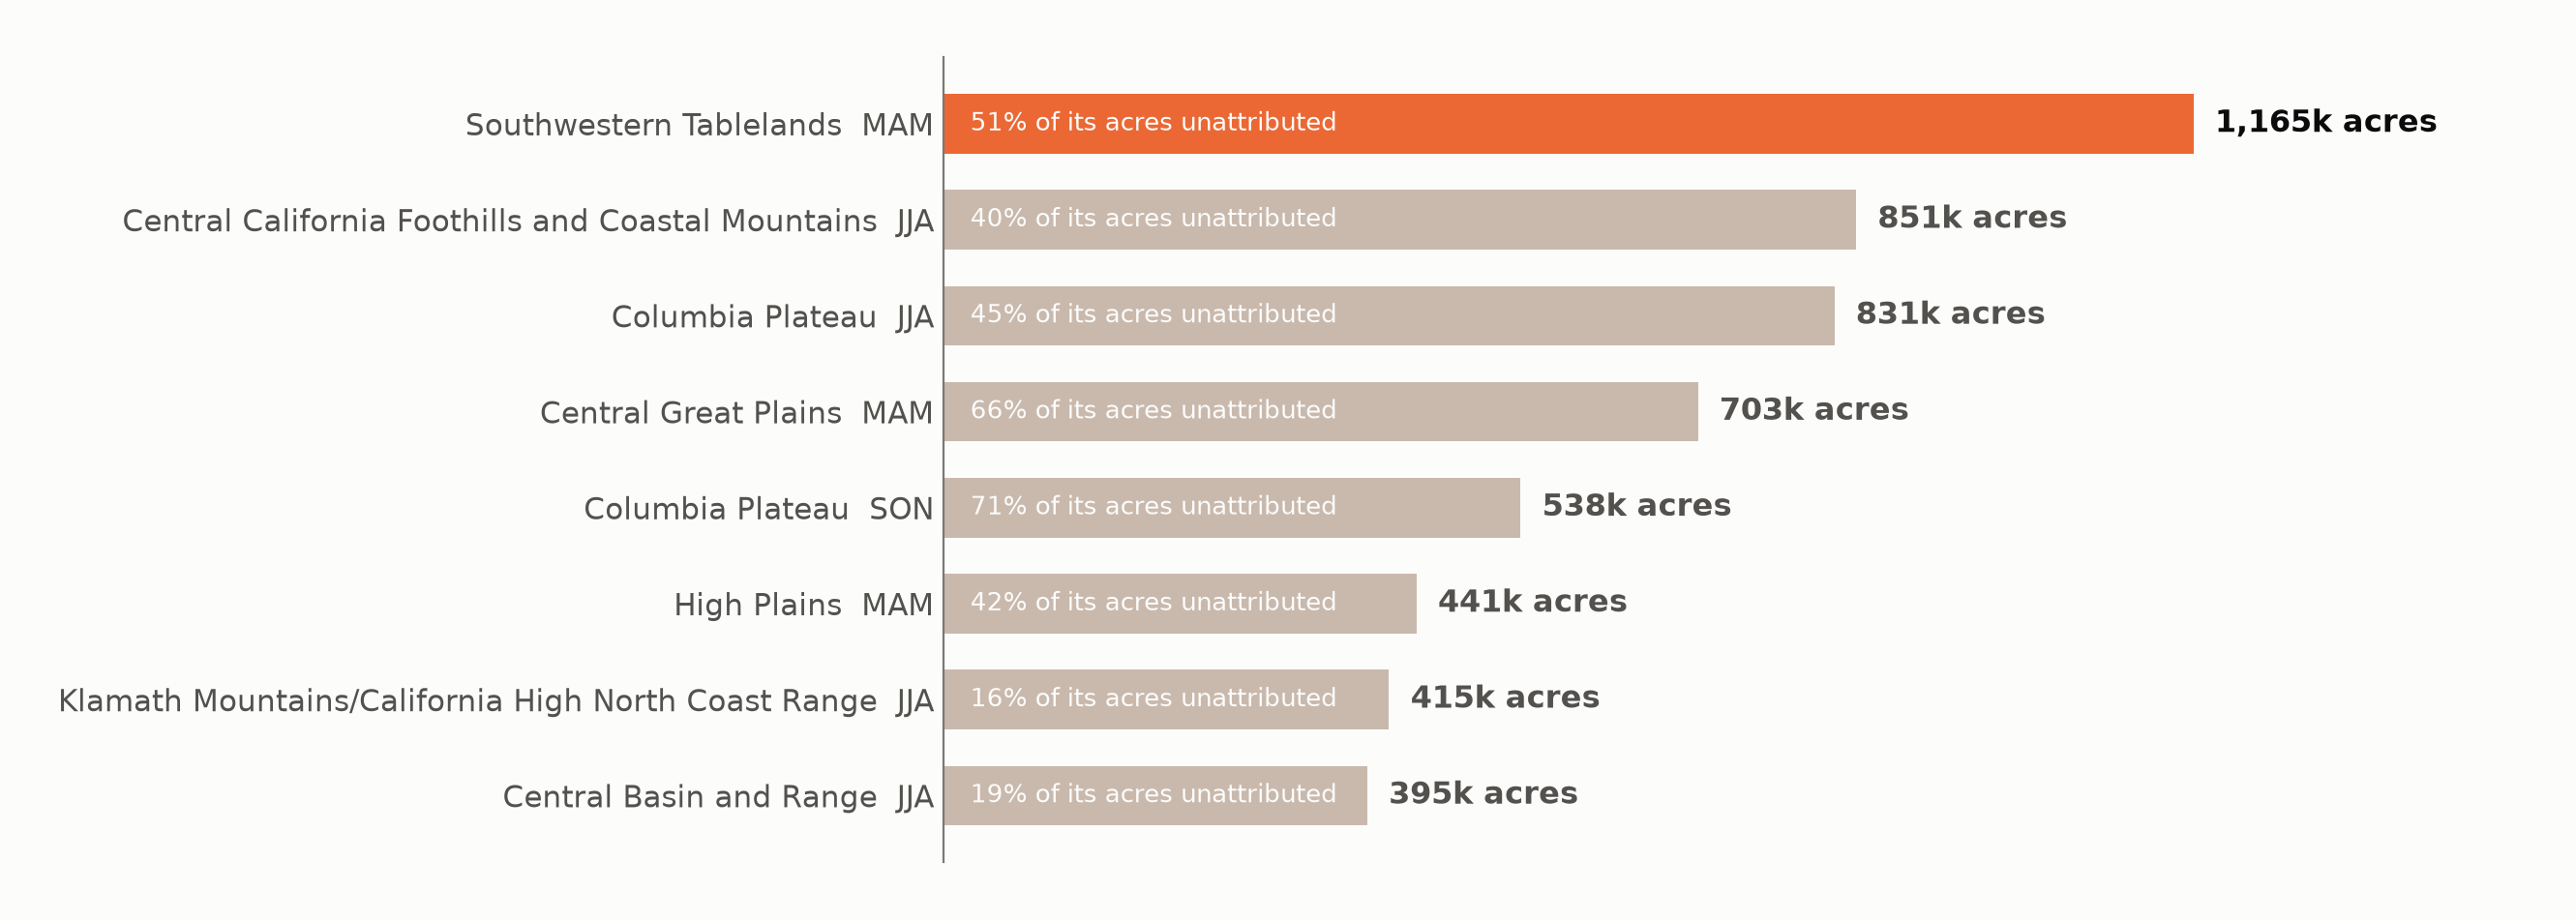

In [8]:
triage = wv.plot_unknown_triage(rsp, IMG / "w6_unknown_triage.png", cfg=cfg)
for k, v in triage.items():
    print(f"  {k:>24}: {v:,.4f}" if isinstance(v, float) else f"  {k:>24}: {v}")

Image(filename=triage["out_path"], width=940)

**The gap is forecastable, and the list says where to spend first.**

Persistence predicts a region-season's missing fraction at acre-weighted **MAE 0.167** against the
global mean's **0.240** — a 31% reduction. Attribution quality is a standing property of a reporting
stream, not a yearly accident, so next season's gap looks like last season's.

**Southwestern Tablelands MAM heads the list at 1.17M predicted unattributed acres.** The ranking is
not the same as ranking by rate, and the figure shows why: Central Great Plains MAM has the worse
attribution rate (66% against 51%) but sits fourth, because it burns less than half as much. Klamath
JJA makes the list at a 16% rate purely on volume.

**This is the one branch whose output is not a forecast for a planner to act on directly.** The other
two rank where to prevent and where to site. This one ranks where the record is too weak to support
either — the acres that Tier 1 can only label "unknown," and the sub-cause model therefore never
sees. Fixing reporting in the top few region-seasons would move more acres into the attributable pool
than anywhere else.

**Scope.** 3,949 held-out region-seasons, forward-chaining, acre-weighted. Rate is the mean missing
fraction across that region-season's held-out years; acres are the sum of predicted unattributed
acres over the same span. `09_unknown_dataquality.ipynb` also ranks by region alone and reports the
regional correlation with natural share (Pearson −0.64) — the missingness concentrates in
human-dominated regions, which is the settled W4 finding.

## Where fires start: the ground the ranking names

Rank every hex in one region by its own prior ignition history — the persistence baseline, from
seasons strictly before the target — then fill in two bands, cut where cumulative captured ignitions
cross 30% and 60%.

**Two bands with a wide lightness gap, not a graded ramp.** The W6 modelling settled that ignition
is a **gate, not a dial**: a hex-season that ignites at all is 22.8x more likely to produce a
≥1,000-acre burn, but escape probability *per ignition* falls with count, and 49% of large fires came
from hexes with exactly one natural ignition. Rank order is supported; graded intensity is not. An
earlier three-tier version shaded 12 / 45 / 97 hexes in adjacent saturations and read as continuous,
asserting exactly the gradation the finding denies. Two well-separated bands read as two decisions,
which is what they are: treat first, treat next, stop.

**The bands are the map's version of the capture curve's first two marks**, so the pair reads as one
argument — the curve gives the rate of decay, the map gives the ground it corresponds to. Both call
the same `siting_ranking`, so they cannot disagree about the order.

Labels sit on leader lines rather than in a legend, anchored to the band member nearest that band's
own centre of mass. Two alternatives were rejected: a raw centroid lands on ground that is not in
the band (the light band wraps around the deep one), and the extreme member on the label's side
points at whichever outlier is furthest out.

          region: Klamath Mountains/California High North Coast Range
           n_hex: 198
     target_year: 2020
           bands: [{'capture_target': 0.3, 'n_hex': 12, 'ground': 0.06060606060606061, 'caught': 0.31693989071038253, 'lift': 5.229508196721311}, {'capture_target': 0.6, 'n_hex': 57, 'ground': 0.2878787878787879, 'caught': 0.6010928961748634, 'lift': 2.088006902502157}]
     n_untreated: 141
   actual_starts: 366
             rho: 0.502
        out_path: ../img/w6_siting_glance.png


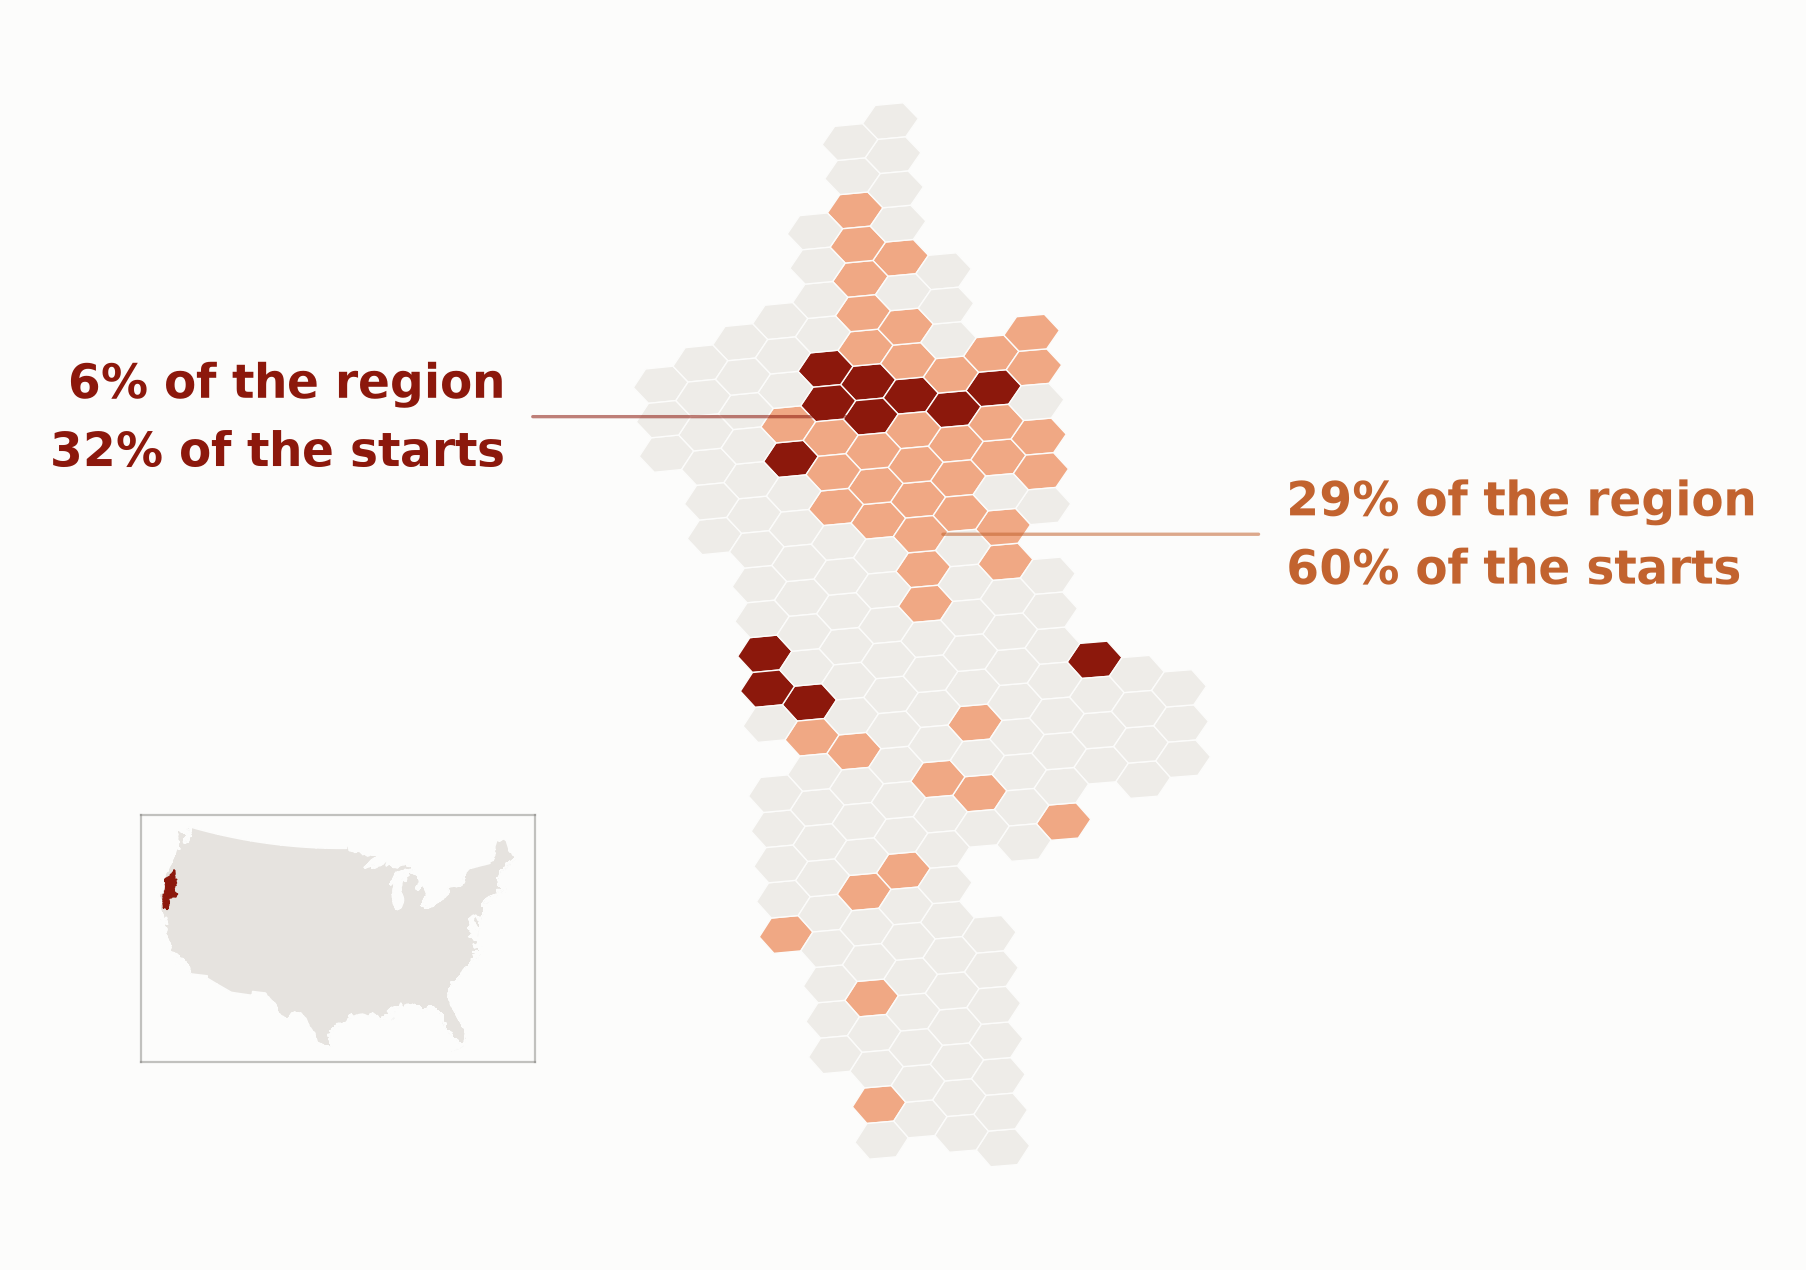

In [9]:
panel = pd.read_parquet(DATA / "hex_panel_modelling.parquet")

site = wv.plot_siting_glance(panel, grid, IMG / "w6_siting_glance.png")
for k, v in site.items():
    print(f"  {k:>14}: {v:.3f}" if isinstance(v, float) else f"  {k:>14}: {v}")

Image(filename=site["out_path"], width=760)

**The first 6% of the region catches a third of next season's starts; the next 23% buys less than the first 6% did.**

| band | ground | starts caught | lift |
| --- | --- | --- | --- |
| deep | 6.1% | 31.7% | **5.23x** |
| light (cumulative) | 28.8% | 60.1% | 2.09x |
| *the light band alone* | *+22.7%* | *+28.4%* | *1.25x* |

The deep band is a tight cluster along one ridge. The light band sprawls across nearly five times
the ground for less than double the capture — the diminishing return, visible geographically rather
than only as a number.

Held-out Spearman for this region-season is +0.50; nationally the same baseline scores **+0.53 on
human ignition and +0.34 on natural**, against shuffled controls within ±0.003 of zero.

## What the ranking is worth beyond its top

The map shows where the first two bands are. The capture curve below carries the same ranking all
the way out, and it is the more sobering of the pair — worth having ready for the first question a
planner would ask: how much of the region do I actually have to treat?

  30% of starts ->   6.1% of ground (5.23x lift)
  60% of starts ->  28.8% of ground (2.09x lift)
  90% of starts ->  77.8% of ground (1.16x lift)


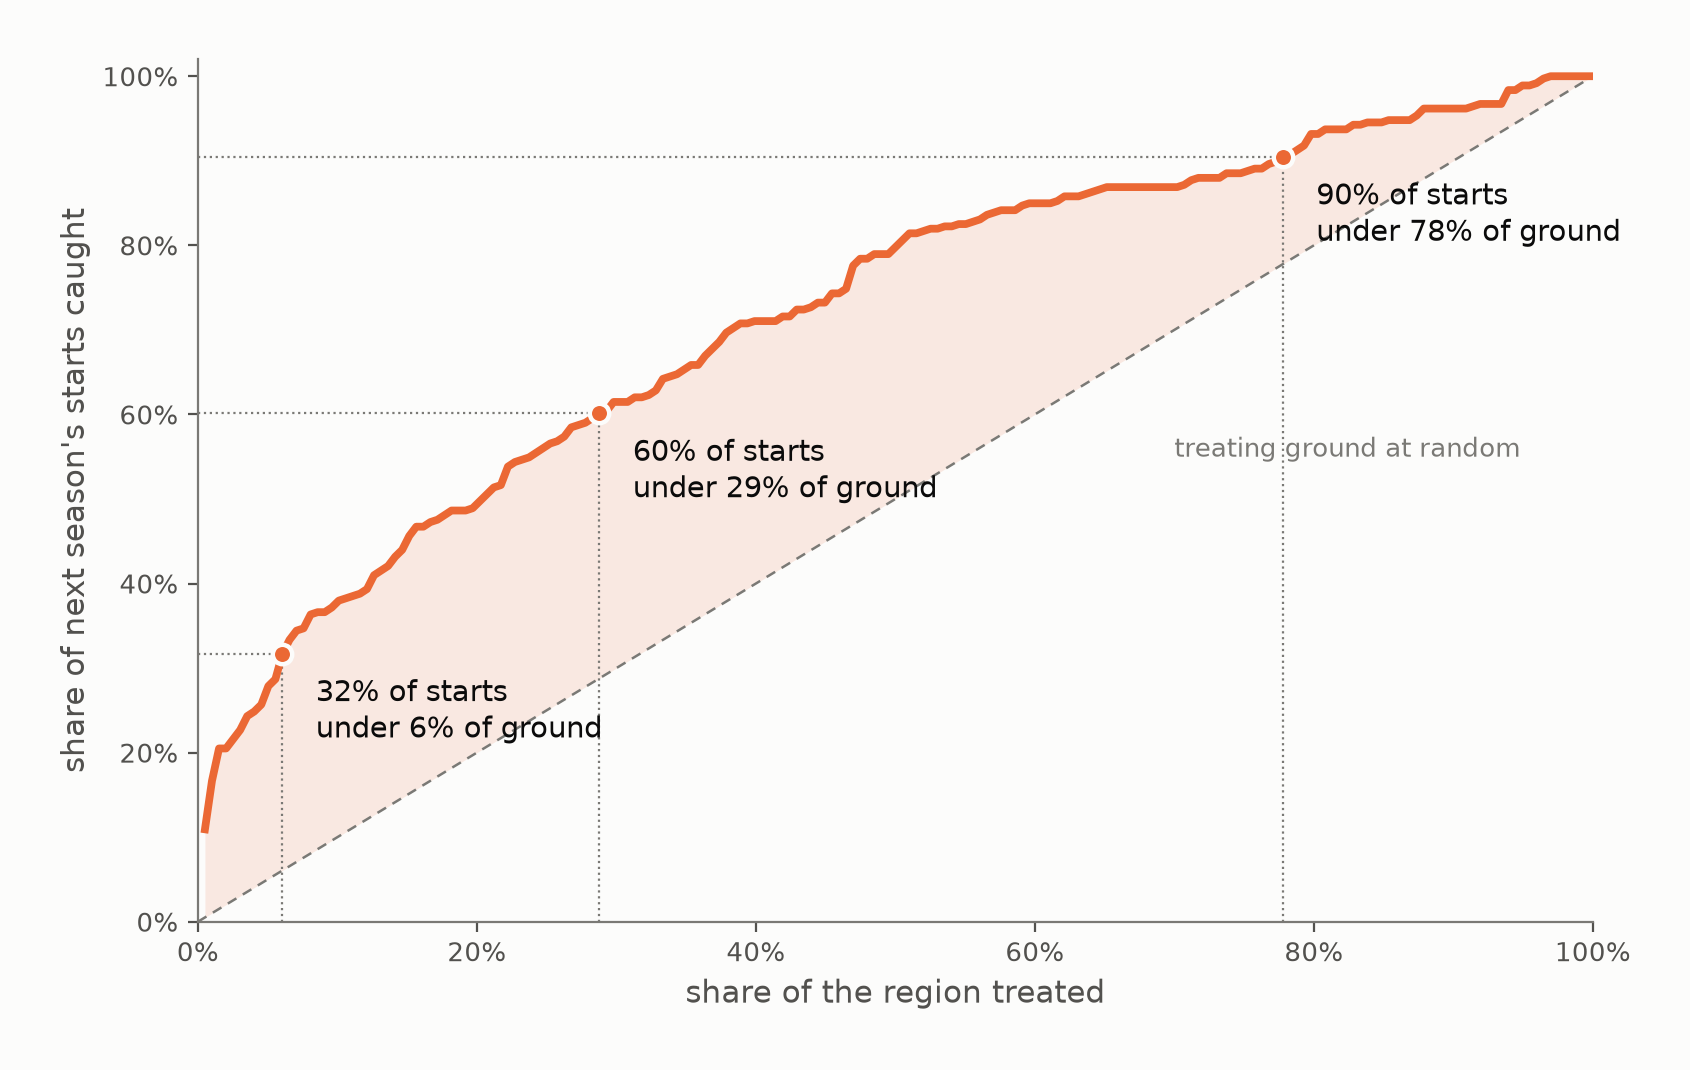

In [10]:
curve = wv.plot_capture_curve(panel, grid, IMG / "w6_capture_curve.png")
for p in curve["points"]:
    print(f"  {p['target']:.0%} of starts -> {p['ground']:6.1%} of ground "
          f"({p['lift']:.2f}x lift)")

Image(filename=curve["out_path"], width=860)

**The return decays fast, and that is the recommendation.**

| starts caught | ground treated | lift over random |
| --- | --- | --- |
| 32% | 6.1% | **5.23x** |
| 60% | 28.8% | 2.09x |
| 90% | 77.8% | 1.16x |

The first few percent of ground is where the ranking earns its keep. Reaching 90% capture takes
77.8% of the region at a 1.16x lift — barely distinguishable from treating everywhere, which is the
posture the project exists to improve on.

**This figure is deliberately less flattering than the map, and both are true.** The map shows 12
hexes and reads as "we know exactly where"; the curve shows a line converging on the diagonal and
reads as "somewhat better than random." The map is the top of the ranking, the curve is all of it. A
reader shown only the map would over-read the result, which is why the curve is kept with it rather
than left out.

**Scope.** One region-season (Klamath JJA 2020, 198 hexes) drawn as an illustration. The general
claim rests on the held-out Spearman values across all regions, not on this map.

## Is that skill real, or a property of the numbers?

A rank correlation of +0.53 cannot by itself distinguish "the ranking knows where fires start" from
"the target has structure this metric rewards." The control that separates them permutes the
persistence predictions **across hexes**: identical values, identical distribution, identical
everything a summary statistic sees — only the pairing with the ground is destroyed. Whatever the
real ranking scores above that is spatial information.

Twenty equal-count strata by predicted value; each point is a stratum's mean prediction against its
mean outcome, with the diagonal drawn as perfect calibration. **Binned rather than raw because 84%
of human hex-seasons record zero starts** — 1.59M points would be a solid blob on the origin.

**Both series in one panel rather than side by side.** Two panels make a reader hold the left shape
in memory to judge the right one, and the flat line only reads as flat *against* the climb.
Superimposed, the two series share an origin and separate — the divergence is the mark itself.

            branch: human
            n_test: 1594296
              bins: 20
        zero_share: 0.8398
          real_rho: 0.5264
          real_mae: 0.4316
      shuffled_rho: 0.0002
      shuffled_mae: 0.7666
          out_path: ../img/w6_shuffled_control.png


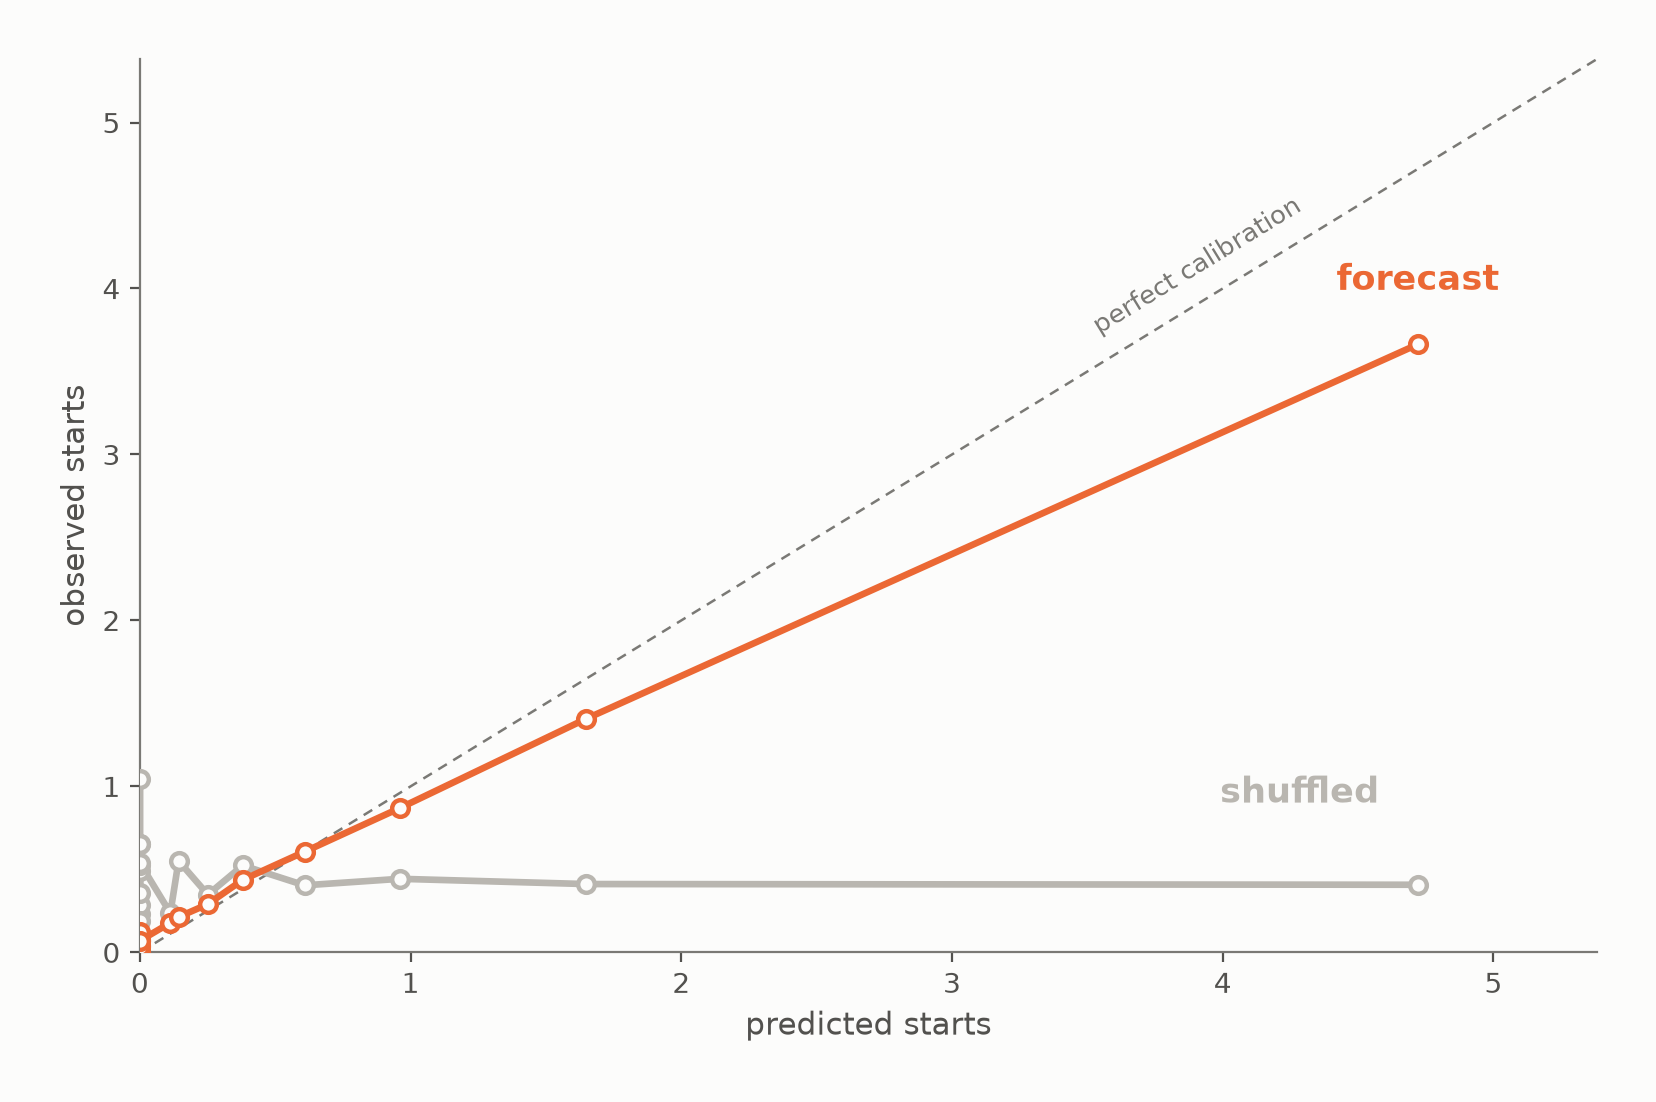

In [11]:
shuf = wv.plot_shuffled_control(panel, IMG / "w6_shuffled_control.png", cfg=cfg)
for k, v in shuf.items():
    print(f"  {k:>16}: {v:.4f}" if isinstance(v, float) else f"  {k:>16}: {v}")

Image(filename=shuf["out_path"], width=960)

**Same numbers, wrong hexes, and the relationship vanishes.**

| | Spearman | MAE |
| --- | --- | --- |
| the ranking | **+0.526** | 0.432 |
| the same numbers, shuffled | +0.0002 | 0.767 |

The real ranking climbs the diagonal — its top stratum is predicted 4.7 starts and observes 3.7.
The shuffled copy is flat at roughly 0.4 across the whole range: the stratum predicted to start
almost five fires observes the same as the stratum predicted to start none.

**Shuffling makes the predictions worse than useless, not merely uninformative.** MAE rises from
0.432 to 0.767, above even the uniform train-mean baseline's 0.703 — a confidently wrong prediction
costs more than no prediction at all. That is what a destroyed pairing looks like.

The same control on the natural branch collapses +0.344 to +0.0002, and a pure random-noise
predictor scores −0.001 on both. Every control sits within ±0.003 of zero, so the +0.53 is not a
metric artefact.

**Scope.** Human branch, 1,594,296 held-out hex-seasons (season-year ≥ 2010), forward-chaining.
Both figures score only cells where persistence is defined, so every baseline sees an identical
population — otherwise the comparison would not be like-for-like. Reproduces
[`12_hex_ignition_baselines.ipynb`](12_hex_ignition_baselines.ipynb) exactly.

## Which branch is predictable, and when?

Held-out Spearman by season for both ignition branches — but scored **one year at a time**, in each
of the 11 held-out years, rather than pooled into a single number per season.

**This is the only figure in the deck that shows a distribution.** Everything else reports a point
estimate, which cannot answer the obvious question: is a difference stable, or is one good year
carrying the average? Eleven independent scores per season-branch answer it for free — the band is
the observed min-to-max range across those years, not a modelled interval, so no distributional
assumption is being made.

The shuffled control is computed per stratum but not drawn. It sits between −0.013 and +0.014 in
every season-year and would render as a third flat line on zero, repeating the previous figure.

                median    min    max  size
branch  season                            
human   DJF      0.529  0.389  0.672    11
        JJA      0.483  0.449  0.559    11
        MAM      0.605  0.527  0.645    11
        SON      0.469  0.321  0.556    11
natural DJF      0.072  0.057  0.180    11
        JJA      0.422  0.372  0.456    11
        MAM      0.201  0.145  0.223    11
        SON      0.190  0.116  0.246    11

                 n_years: 11
          n_season_years: 44
     natural_beats_human: 0
             human_range: (0.3213817861208755, 0.6721158677797047)
           natural_range: (0.05673726394205205, 0.4558539231326864)
          shuffled_range: (-0.013291579283787908, 0.013590559294789795)
                out_path: ../img/w6_season_skill.png


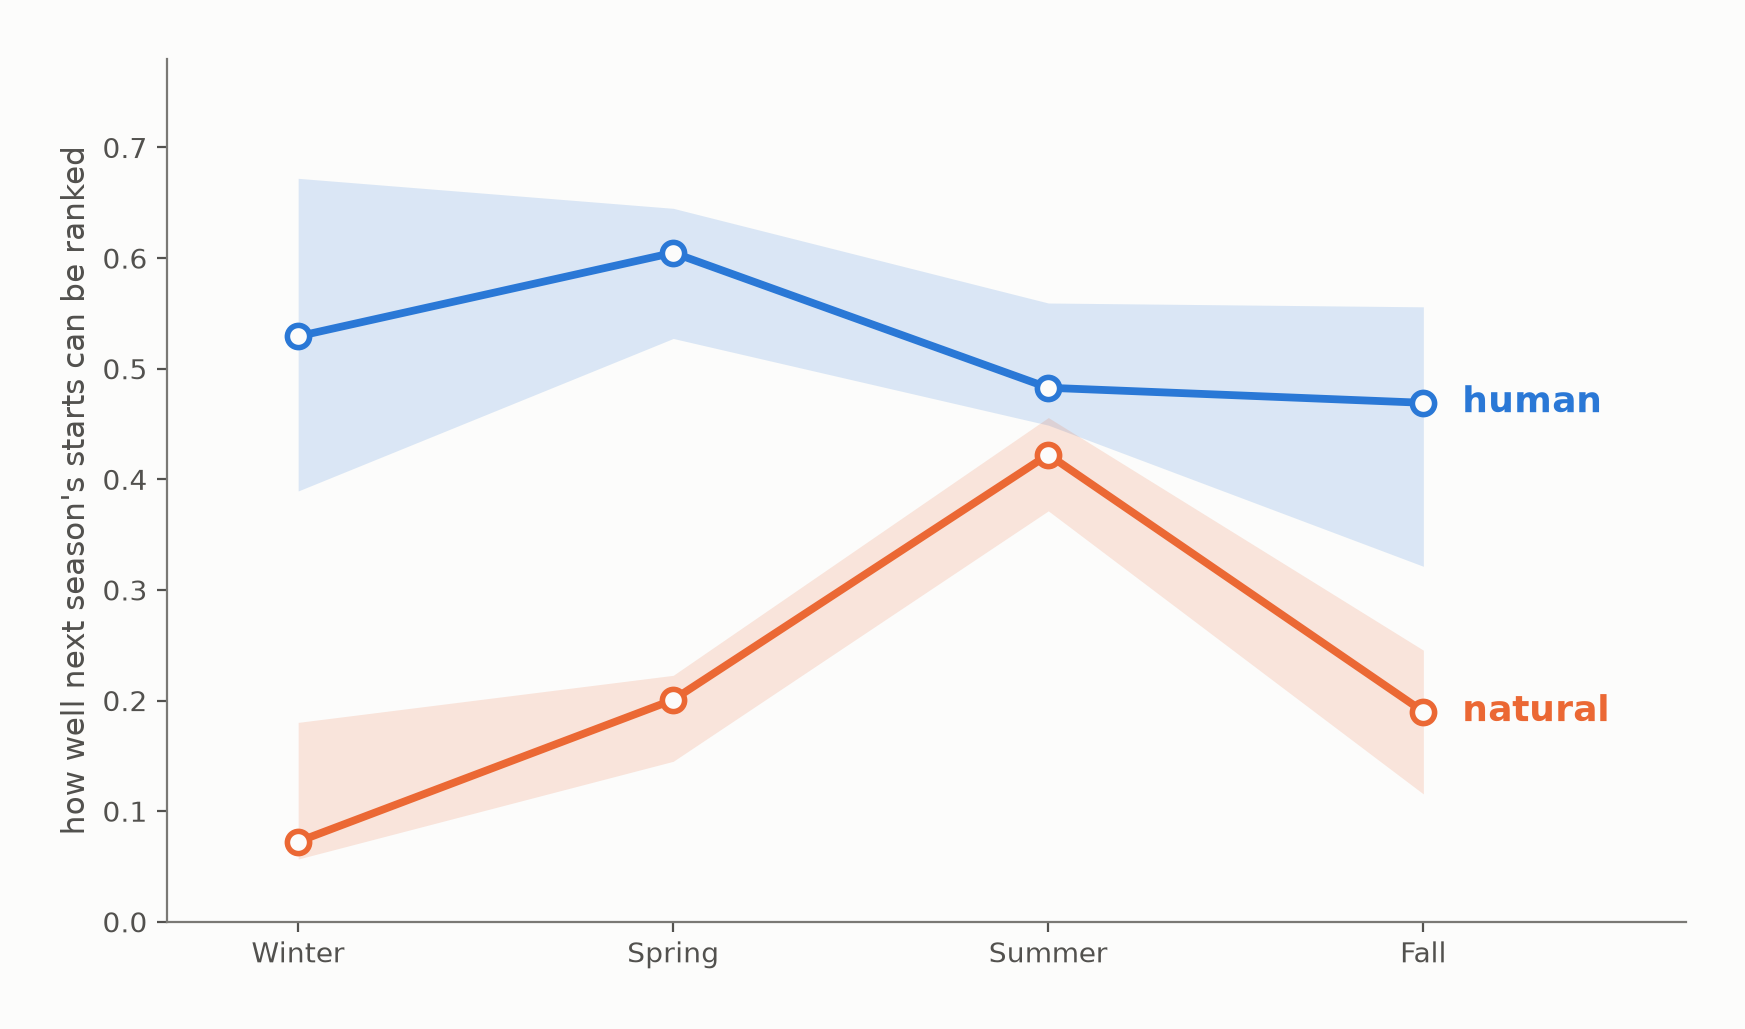

In [12]:
seasonal = wv.season_predictability(panel, cfg=cfg)
print(seasonal.groupby(["branch", "season"])["rho"]
      .agg(["median", "min", "max", "size"]).round(3).to_string())

skill = wv.plot_season_predictability(panel, IMG / "w6_season_skill.png", cfg=cfg)
print()
for k, v in skill.items():
    print(f"  {k:>22}: {v}")

Image(filename=skill["out_path"], width=920)

**Human fire is predictable year-round; lightning only in summer.**

Medians across the 11 held-out years, with the observed range beneath:

| season | human | natural |
| --- | --- | --- |
| DJF | 0.529 (0.39–0.67) | 0.072 (0.06–0.18) |
| MAM | **0.605** (0.53–0.65) | 0.201 (0.15–0.22) |
| JJA | 0.483 (0.45–0.56) | **0.422** (0.37–0.46) |
| SON | 0.469 (0.32–0.56) | 0.190 (0.12–0.25) |

**Human beats natural in all 44 season-years, without exception.** The closest approach is JJA,
where human's worst year (0.449) still sits below natural's best (0.456) — but those are different
years, and within any single year the ordering never reverses. That is a stronger statement than the
pooled numbers alone can make.

**Why the shapes differ.** Where people are does not change with the season, so a hex's own human
ignition history describes it in December as well as in June. Lightning is a summer phenomenon:
78.1% of natural ignitions fall in JJA, and outside summer there is barely a signal to persist —
natural's winter median of +0.07 is close to nothing.

**Two things the bands reveal that the point estimates hid.** Winter is human's least certain season
(0.39–0.67, the widest band) because there are fewer fires to rank. JJA is the most stable for both
branches, which is convenient: summer is when the acres are.

**Note on the medians.** These are medians of 11 per-year scores and differ slightly from the pooled
figures quoted elsewhere (e.g. JJA human 0.483 here against +0.488 pooled) — pooling weights every
hex-season equally across years, while the median weights every year equally. Both are correct for
what they measure; this figure uses per-year scoring because that is what produces a distribution.

**What this figure does not show.** No road layer was ever built and joined to the hex grid, so
"people start fires where the roads are" remains an *inference* from the spatial stability, not a
measured mechanism — see the Q&A note in `coursework/W6/talk_notes.md`. What is measured is that
human ignition persists in space better than anything else in the project.

**Scope.** 398,574 held-out hex-seasons per season-year, forward-chaining, season-year ≥ 2010.

## Beat 12 — the repair attempt, and its verdict

Beat 11 leaves a failure on the table: the forecast comes apart on exactly the cells that hold the
acres. Beats 12–14 are what was done about it. Drought and fuel-load layers were sourced to fix that
failure, and this figure is the verdict on the ignition half of the attempt.

**Both branches on one population.** JJA, the six forest ecoregions the MODIS probe was fetched for,
held out 2010+, **29,293 cells** — the same cells for both lines, so they are directly comparable
and the figure needs no scope caveat on the slide.

**The numbers are transcribed, not recomputed.** They come from the notebooks that ran the ablations
(`12_hex_ignition_baselines` cell 29 for natural, `14_hex_human_branch` cell 15 for human), and are
hardcoded in `IGNITION_LADDER` so the figure cannot silently drift from the published table. The
cell below prints them next to the transcription for checking.

**Two design decisions worth stating**, because both are ways this figure could have lied:

- **The y-axis starts at zero.** Cropping to the data would turn moves of 0.004 into visible steps
  and manufacture the signal the beat says is absent. A null has to be drawn on a scale where a real
  effect *would* have shown.
- **No values on the points.** The number that matters is the one that is not there. A reader
  comparing four decimal places has stopped seeing the shape.


              n_test: 29293
       natural_floor: 0.4235
         human_floor: 0.4863
        natural_span: 0.0050
          human_span: 0.0183
   natural_best_gain: 0.0045
     human_best_gain: 0.0000
              source: notebook/12_hex_ignition_baselines.ipynb cell 29; notebook/14_hex_human_branch.ipynb cell 15
            out_path: ../img/w6_ignition_ladder.png

transcribed rungs (higher is better):
     human: +0.4863 +0.4680 +0.4818 +0.4807
   natural: +0.4235 +0.4280 +0.4278 +0.4230
     rungs: ["the region's own history", '+ drought', '+ fuel load', '+ both']


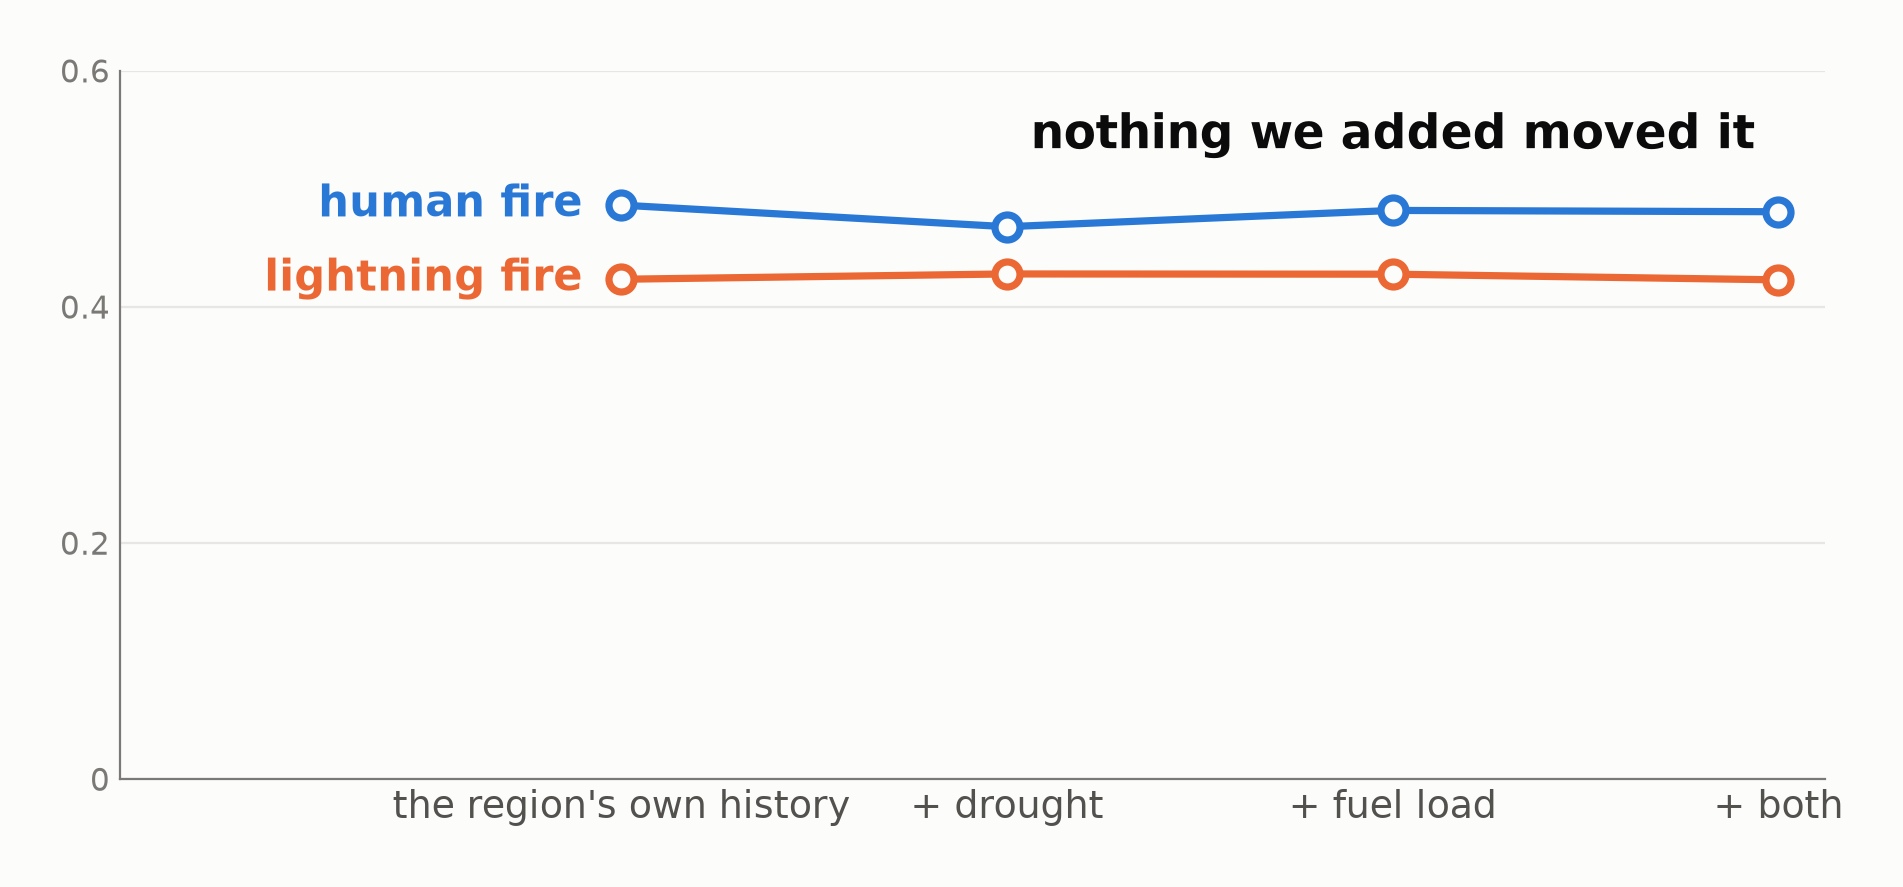

In [13]:
led = wv.plot_ignition_ladder(IMG / "w6_ignition_ladder.png")
for k, v in led.items():
    print(f"  {k:>18}: {v:.4f}" if isinstance(v, float) else f"  {k:>18}: {v}")

print("\ntranscribed rungs (higher is better):")
for br in ("human", "natural"):
    row = " ".join(f"{v:+.4f}" for v in wv.IGNITION_LADDER[br])
    print(f"  {br:>8}: {row}")
print(f"  {'rungs':>8}: {wv.IGNITION_LADDER['rungs']}")

Image(filename=led["out_path"], width=940)


**Nothing we added moved it.** Four specifications, two branches, and both lines are flat.

| rung | human | lightning |
| --- | --- | --- |
| the region's own history | **0.4863** | **0.4235** |
| + drought | 0.4680 | 0.4280 |
| + fuel load | 0.4818 | 0.4278 |
| + both | 0.4807 | 0.4230 |

The best gain anywhere is **+0.0045** (lightning, + fuel load) and every human rung is *negative*.
Counting the ladders in notebooks 12 and 14 together this is the fifth consecutive covariate null on
an ignition target.

**Why the flatness is the finding, not a failure to tune.** An ablation alone cannot separate "the
model failed to use the covariate" from "the covariate carries nothing usable." Notebook 12 cell 27
separates them without a model: converting climate to a within-hex anomaly collapses it — pdsi
−0.137 → **−0.073**, water_deficit +0.160 → **−0.004** — and NDVI does the same, +0.228 → **+0.098**.
The covariates describe *dry places*, not *dry years*, and a hex's own ignition history already
encodes place more completely than four climate variables can.

**What this does not claim.** These are *pre-season* covariates. Nothing here says same-day
conditions — wind, timing, suppression availability — cannot predict ignition or escape. That is a
different model with a different data requirement, and it is the open question beat 15 concedes.

**Scope.** JJA, six forest ecoregions, held out 2010+, 29,293 cells, ranking skill as Spearman.


## Beat 13 — the same ladder, on acres, and one rung lifts

Beat 12 ran four rungs against *where fires start* and got a flat line. This is the same experiment
against *how much burns*, and it is the one place in the project where a covariate earned its keep.

**The figure is deliberately the same figure** — same rung labels, same axis, same zero-based scale,
one line instead of two. The beats are one experiment run against two targets, so the shape changing
*is* the argument. A viewer who has just read beat 12's flat line should recognise this one instantly
and see the last point leave the baseline.

**What differs, and why the two are not cell-for-cell comparable.** Different target (burned area
given a burn, not ignition counts), different baseline (burn-conditional persistence), and a much
smaller test set — **7,799** burning JJA cells against beat 12's 29,293 hex-seasons. Same six forest
ecoregions. Comparable in shape; not a like-for-like number.

**Why the y-axis still starts at zero, when the finding is a gain.** The same reason as beat 12,
running the other way. Cropping until +0.049 filled the frame would inflate a result that beat 14
then has to deflate — and a deck that magnifies its one positive result and flattens its nulls is
arguing by axis choice. The floor rule carries the comparison instead.

Transcribed from `13_hex_acres_baselines` cell 15; see `ACRES_LADDER`.


            n_test: 7799
             floor: +0.2582
              best: +0.3075
              gain: +0.0493
     drought_alone: -0.0078
        fuel_alone: +0.0010
       shuffled_sd: +26.6000
            source: notebook/13_hex_acres_baselines.ipynb cell 15
          out_path: ../img/w6_acres_ladder.png

transcribed rungs (higher is better):
  +0.2582  the region's own history
  +0.2504  + drought
  +0.2592  + fuel load
  +0.3075  + both

held across split years 2008-2016: [0.012, 0.048, 0.062, 0.062, 0.066]


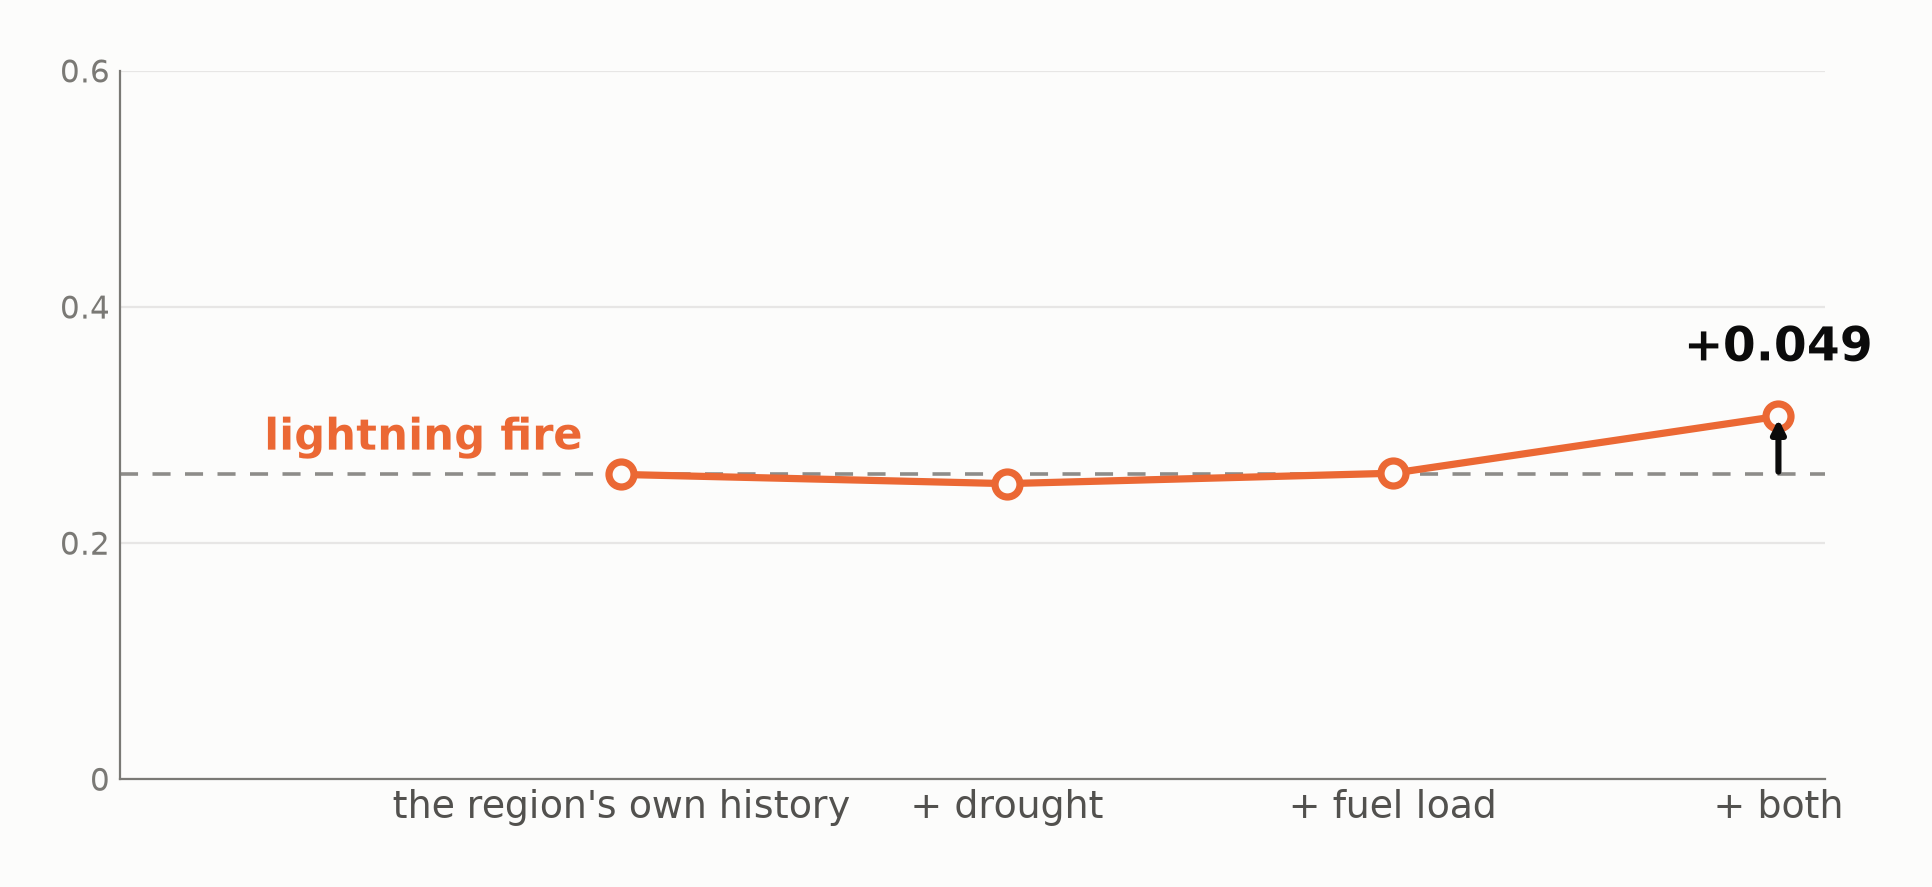

In [14]:
acr = wv.plot_acres_ladder(IMG / "w6_acres_ladder.png")
for k, v in acr.items():
    print(f"  {k:>16}: {v:+.4f}" if isinstance(v, float) else f"  {k:>16}: {v}")

print("\ntranscribed rungs (higher is better):")
for r, v in zip(wv.ACRES_LADDER["rungs"], wv.ACRES_LADDER["natural"]):
    print(f"  {v:+.4f}  {r}")
print(f"\nheld across split years 2008-2016: {wv.ACRES_LADDER['split_years']}")

Image(filename=acr["out_path"], width=940)


**Fuel load and fuel dryness are jointly necessary, and neither is sufficient.**

| rung | Spearman | vs. floor |
| --- | --- | --- |
| the region's own history | 0.2582 | — |
| + drought | 0.2504 | **−0.0078** |
| + fuel load | 0.2592 | +0.0010 |
| + both | **0.3075** | **+0.0493** |

A combination beating both of its parts is the pattern most likely to be a modelling artifact, so
notebook 13 put it through two checks before reporting it.

**Check 1 — is it the covariates?** Shuffling the covariates across cells while holding persistence
intact *degrades* the model: −0.0129 mean, never better than −0.0103, against the real +0.0493.
That is **26.6 SD** of separation. It also held across five forward-chaining split years (+0.012,
+0.048, +0.062, +0.062, +0.066), so it is not one lucky partition.

**The physical reading.** Wet heavy fuel will not carry fire; dry bare ground has nothing to burn.
Either variable alone describes half of a conjunction, which is why either alone is worth nothing.

**Check 2 is beat 14, and it fails.** The gain is real and it lands in deciles 6–8 — 1 to 20 acre
cells — while the top decile goes 855x under to 868x under. That is the next beat, and it is why
this one is a setup rather than a conclusion.

**Scope.** JJA natural magnitude, six forest ecoregions, held out 2010+, 7,799 burning cells.


## Beat 14 — where the gain lands

Beat 13's +0.049 is real: it survived a covariate-shuffled control at 26.6 SD and held across five
split years. This is the second check, and it is the one that fails.

**Beat 11's axis, reused a third time** — cells ordered by acres burned least to most, typical error
on a log scale. Beat 10 established that the right edge holds 98% of the acres; beat 11 showed the
forecast coming apart there; this shows the covariates failing to fix it. Three beats landing the eye
on the same place is the deck's argument for reframing rather than tuning.

**Both lines on one panel, not side by side.** The claim is about the *gap between them* — opening in
the middle, closing at the right — and a gap is only readable when both lines share an axis.

**The damage is shaded as well as the gain.** Deciles 1–5 get materially worse, and a figure showing
only the win would misreport the trade.

Transcribed from `13_hex_acres_baselines` cell 19; see `GAIN_DECILES`.


    improved_deciles: [6, 7, 8, 9]
    worsened_deciles: [1, 2, 3, 4, 5, 10]
         top_floor_x: 854.85
         top_model_x: 867.80
    top_median_acres: 5,072.58
      worst_damage_x: 1.98
        n_per_decile: 780
              source: notebook/13_hex_acres_baselines.ipynb cell 19
            out_path: ../img/w6_gain_landing.png

by decile (typical x-off):
  dec      acres     floor     model   verdict
    1       0.10     18.81     35.89   worse
    2       0.10     13.08     23.15   worse
    3       0.20      5.68     11.23   worse
    4       0.35      3.42      6.63   worse
    5       0.70      3.21      4.09   worse
    6       1.50      3.51      2.67   better
    7       4.20      5.00      2.69   better
    8      20.30      9.01      4.16   better
    9     199.55     25.34     24.33   better
   10   5,072.58    854.85    867.80   worse


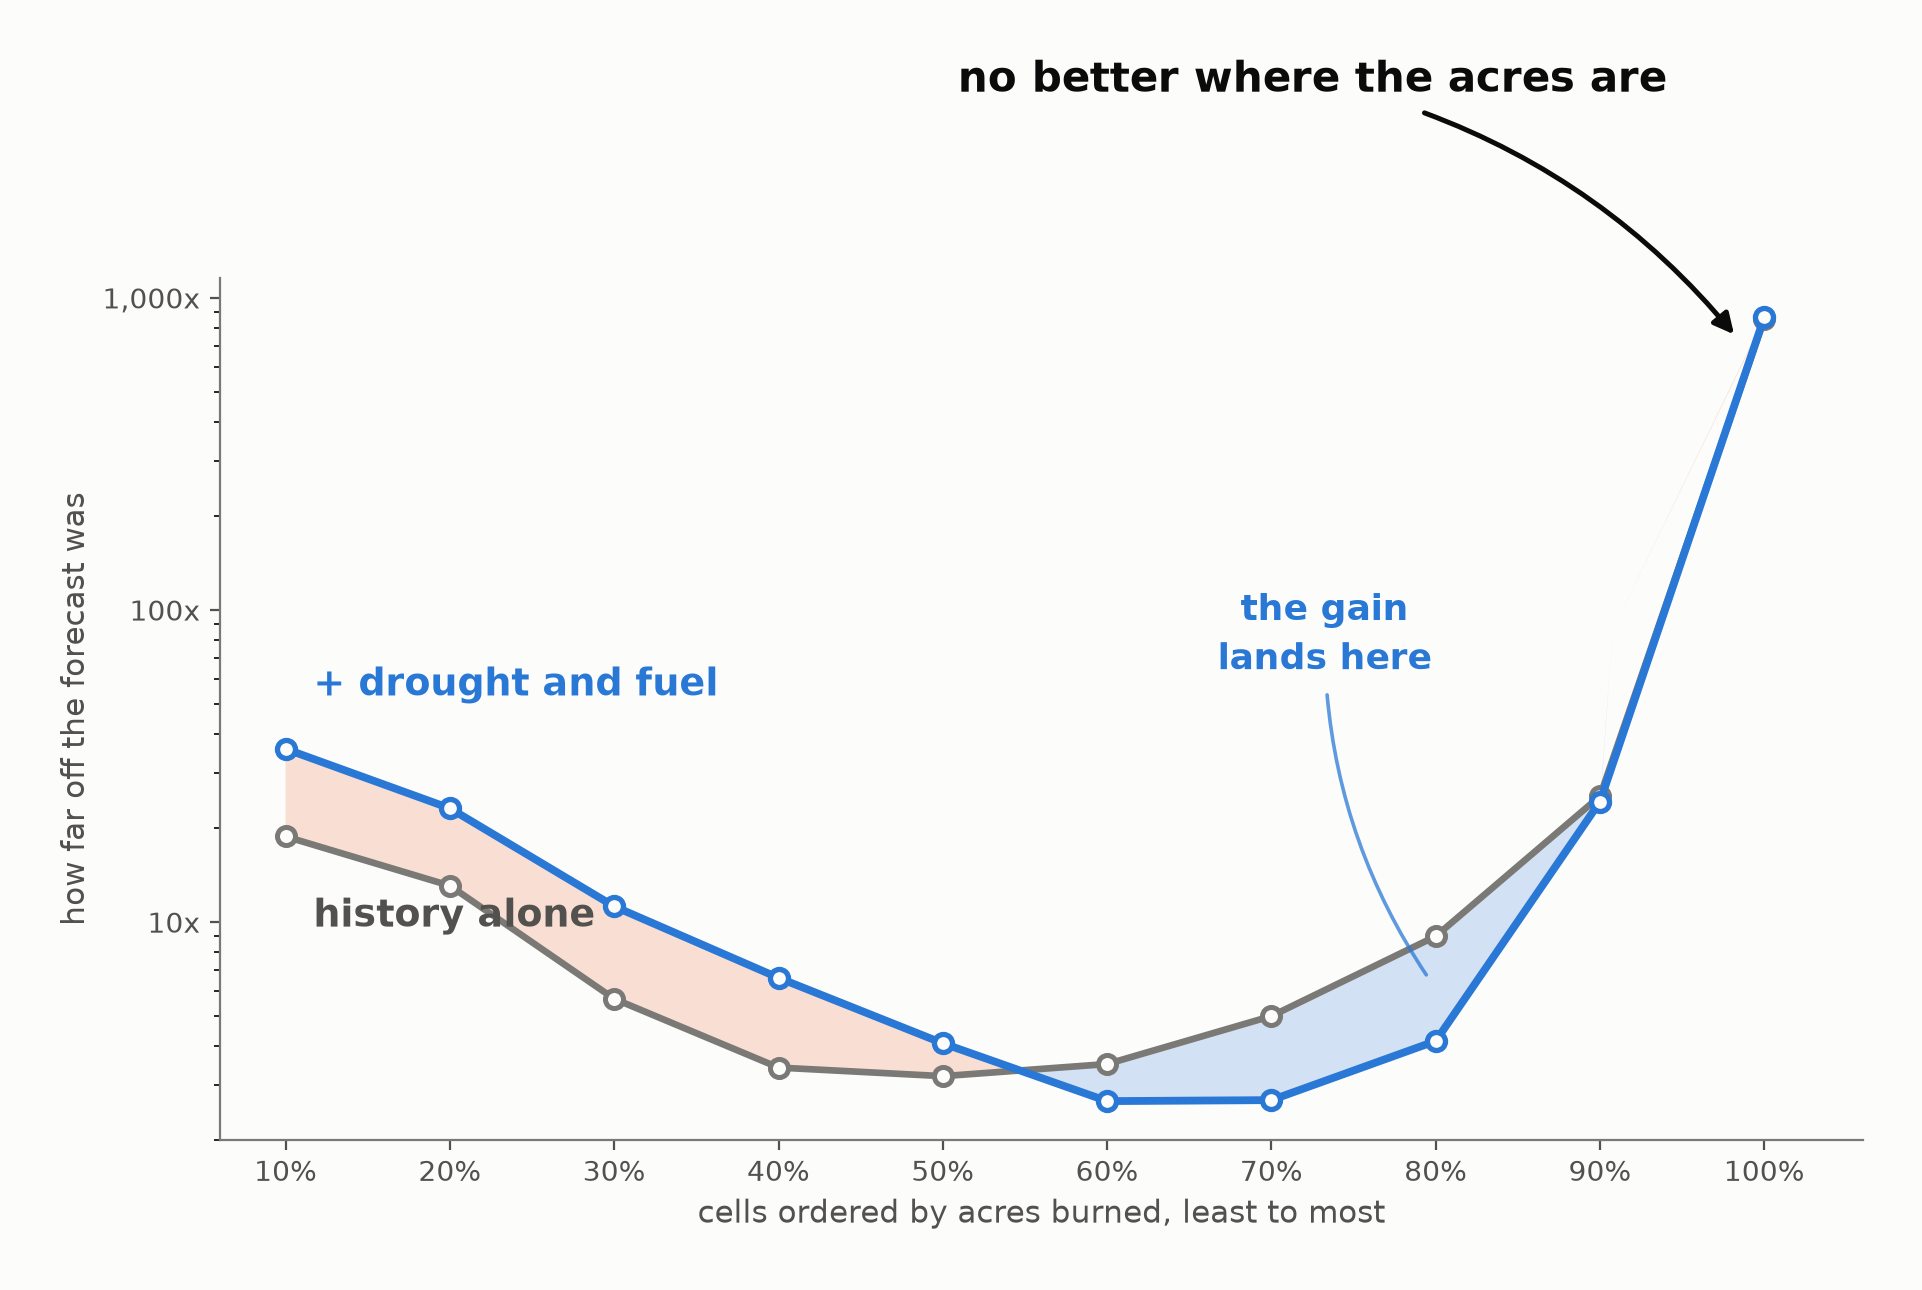

In [15]:
gl = wv.plot_gain_landing(IMG / "w6_gain_landing.png")
for k, v in gl.items():
    print(f"  {k:>18}: {v:,.2f}" if isinstance(v, float) else f"  {k:>18}: {v}")

print("\nby decile (typical x-off):")
g = wv.GAIN_DECILES
print(f"  {'dec':>3} {'acres':>10} {'floor':>9} {'model':>9}   verdict")
for d, a, f, m in zip(g["decile"], g["median_acres"], g["floor_x"], g["model_x"]):
    print(f"  {d:>3} {a:>10,.2f} {f:>9,.2f} {m:>9,.2f}   "
          f"{'better' if m < f else 'worse'}")

Image(filename=gl["out_path"], width=940)


**The gain is real, and it lands where nothing was at stake.**

Deciles 6–9 improve — cells of roughly 1 to 200 acres — with typical error falling from 3.5x to 2.7x
at decile 6 and 9.0x to 4.2x at decile 8. Deciles 1–5 get **worse**, decile 1 nearly doubling from
18.8x to 35.9x. And the top decile, a median cell of **5,073 acres**, goes from 855x under to
**868x** under: no improvement at all.

**Why that is fatal rather than disappointing.** Beat 10 measured the concentration: the
worst-burning 10% of cells hold **98%** of natural acres, the worst-burning 1% hold 55%. A rank-metric
gain living in deciles 6–9 is a gain over cells that hold a rounding error's worth of the burn. The
model got better at the fires a planner never needed a forecast for.

**What this closes, and what it does not.** It closes pre-season covariates as a route to the tail —
five nulls on ignition and one real-but-useless gain on acres. It does **not** close same-day
conditions, which were never tested and are a different data requirement entirely. That distinction
is beat 15's, and keeping it precise is what makes the concession credible rather than defeatist.

**Scope.** JJA natural magnitude, six forest ecoregions, held out 2010+, 780 cells per decile.


## Beat 15 — the concession, as a grain problem

The pivot of the deck. Beats 10–14 descend: the acres are in the tail, the forecast fails there, and
the covariates do not fix it. Beat 16 opens the recovery. Without beat 15 those two read as a failure
followed by an unrelated consolation.

**This figure plots no data, and it is about the method rather than the fire.** Both are deliberate.
Every number the beat could show has already been shown — the tail failure is beat 11, the
concentration beat 10, the covariate nulls 12–14 — and re-plotting any of them invites the audience
to re-audit numbers at the one moment the talk needs them accepting a conclusion.

**What it draws instead is the parallel.** Beat 7 fixed a forecast by dropping grain in *space*: the
region was too coarse to site anything, so the map broke into hexes. The tail failure is the same
defect on the *time* axis — a season is too coarse a unit to say how big a fire gets, when what makes
a fire run is the wind on one afternoon. The deck cannot fix that one, because same-day data is a
different acquisition project.

The solved row is closed and ticked; the untested row is dashed. One drop is a result, the other a
hypothesis, and the asymmetry is the honesty.


solved  : the region -> the hex
untested: the season -> the day


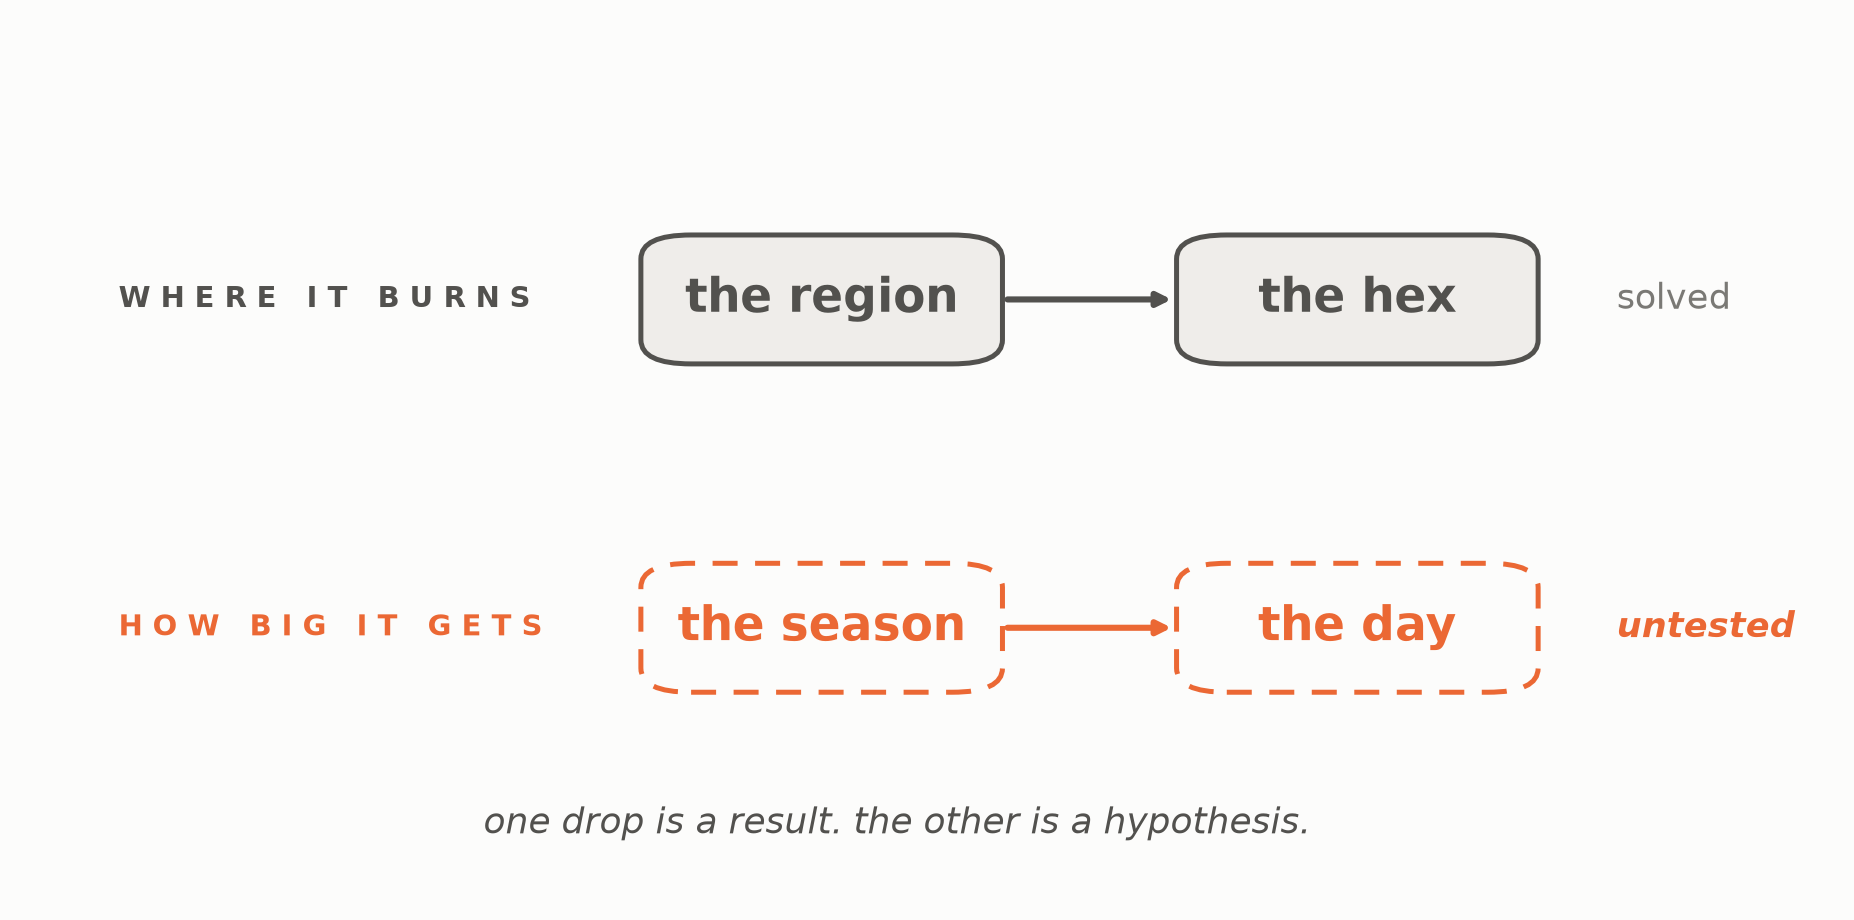

In [16]:
gp = wv.plot_grain_parallel(IMG / "w6_grain_parallel.png")
print("solved  :", " -> ".join(gp["solved"]))
print("untested:", " -> ".join(gp["untested"]))

Image(filename=gp["out_path"], width=940)


**Megafire size is not forecastable before the season — and the reason has a shape.**

What licenses the claim is the exhaustiveness of the pre-season attempt: five covariate ablations on
ignition targets across two branches (beat 12), and on acres a gain that was real, survived a
shuffled control at 26.6 SD, and still moved the top decile only from 855x to 868x (beats 13–14).
Every layer in that attempt is known before the season opens — the property that makes it useful for
planning and, apparently, useless for the tail.

**The fourth instance of one lesson.** This is where the project's separate nulls turn out to be the
same null:

| where | the mismatch |
| --- | --- |
| W4 pooled climate | real per-region signal averaged to zero across 105 regions — *"the covariates are real but the grain of the model is wrong"* |
| beat 12 | the covariates identify dry **places**, not dry **years** |
| beat 7 | the region was too coarse to site anything; the hex was not |
| beat 15 | the season is too coarse to size a fire; the day might not be |

Three of those were diagnosed separately before anyone noticed they were one thing. Naming it here is
what turns beat 15 from a dead end into a direction.

**What the beat does not claim.** It does not say megafire size is unpredictable in principle. Wind,
ignition timing and suppression availability were never tested, and they are not pre-season
quantities — a same-day model is a different data requirement, not a tuning exercise on this one.
`CLAUDE.md` carries this as the one genuinely open question the W6 nulls leave.

**On the headline change.** It previously read *"Megafire size is not forecastable before the season.
Stop targeting it"* — a null plus an instruction, which left beat 16 looking like an unrelated
consolation. The grain framing makes it a diagnosis, and a diagnosis points somewhere. The
instruction survives in the BLUF and beat 19.


## Beat 16 — the reframe: ignition is the gate

Beat 15 concedes that megafire size is not forecastable before the season. This is the door it left
open. The premise is not statistical but physical: **a megafire is not a separate kind of event, it
is a small fire that escaped.** If that is true, the leverage moves upstream to the ignition — which
is exactly the quantity beat 7 showed to be the most predictable surface in the project.

That reframes a null as a recommendation, so notebook 13 tested it rather than asserting it. Two
questions with different answers: *is ignition a gate* (this beat, yes) and *does ignition count rank
big-fire risk* (beat 17, no).

**The encoding.** Two bars in a common frame, no axis. This is the deck's only comparison of two
probabilities, so it uses the plainest form available rather than reusing an axis the audience has
learned. Both percentages are printed because at true scale the 0.29% bar is nearly invisible — which
is the finding, not a drawing problem.

Transcribed from `13_hex_acres_baselines` cell 22; see `GATE`.


  P(>=1,000 ac | no ignition) : 0.00294
  P(>=1,000 ac | >=1 ignition): 0.06694
  gate ratio                       : 22.8x


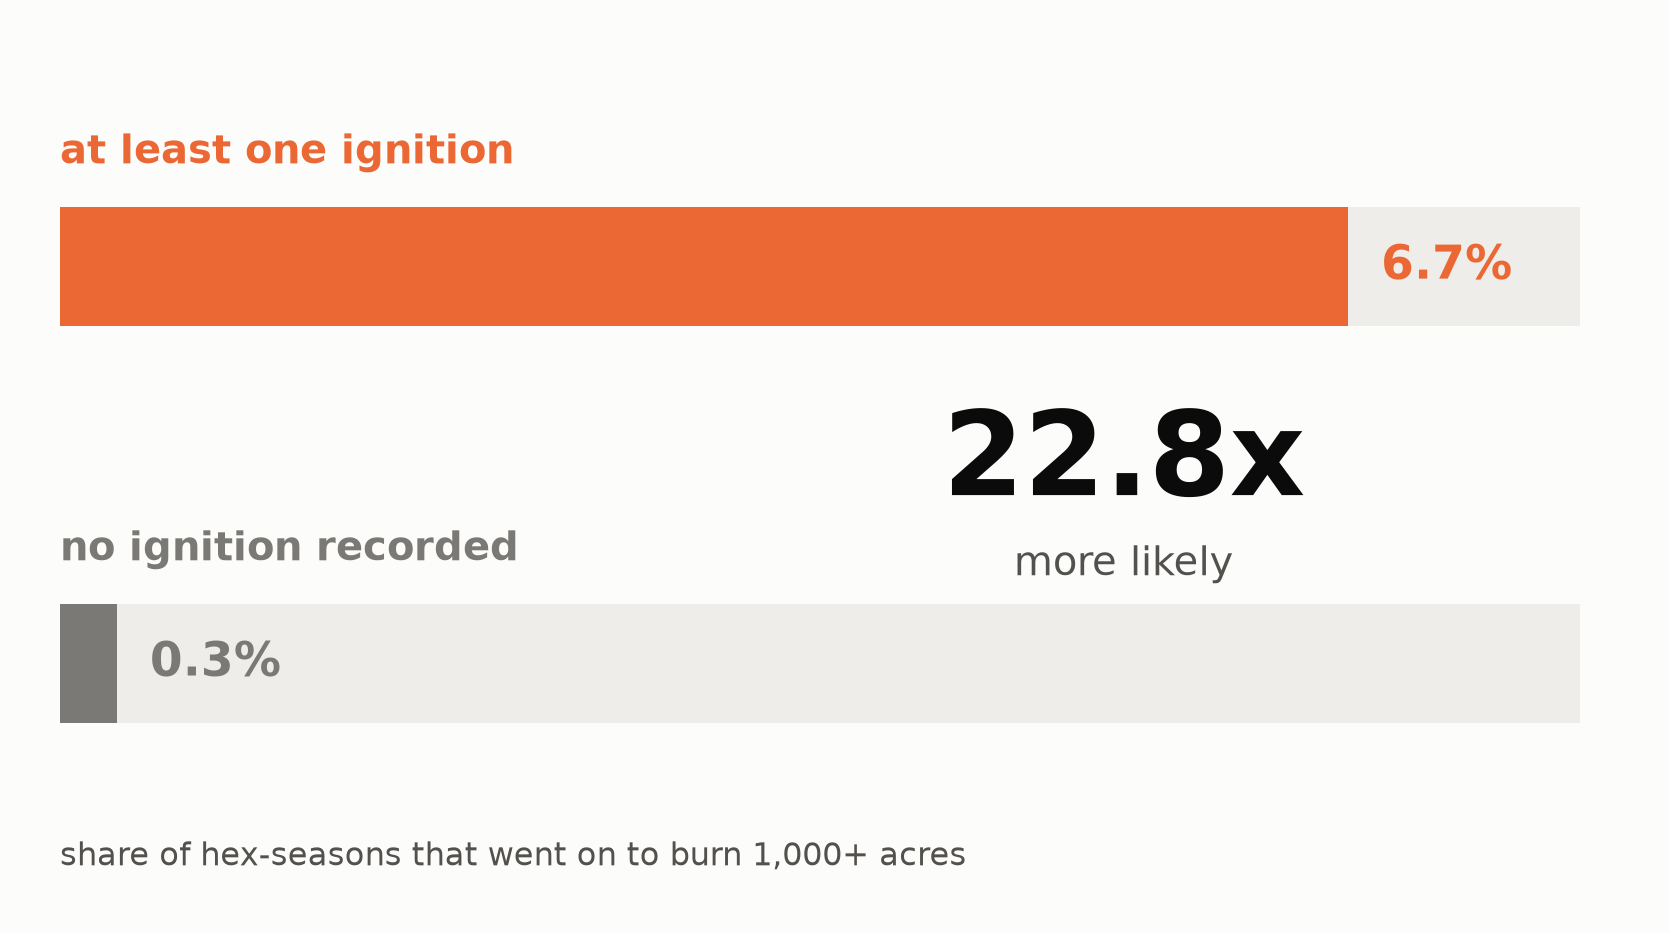

In [17]:
gt = wv.plot_ignition_gate(IMG / "w6_ignition_gate.png")
print(f"  P(>={gt['big_acres']:,} ac | no ignition) : {gt['p_none']:.5f}")
print(f"  P(>={gt['big_acres']:,} ac | >=1 ignition): {gt['p_some']:.5f}")
print(f"  gate ratio                       : {gt['ratio']:.1f}x")

Image(filename=gt["out_path"], width=900)


**Ignition is a genuine gate.** A hex-season that ignites at all is **22.8x** more likely to produce
a 1,000-acre burn than one that does not: **6.7%** against **0.29%**.

**Why this rescues the recommendation rather than consoling it.** Beats 10–14 establish that the
acres live in the tail and the tail is not forecastable from anything available before the season.
That would be a dead end if burned area were the only thing a planner could site against. It is not.
The gate says the consequential burns are drawn almost entirely from the igniting cells, and beat 7
says which cells those are — held-out Spearman +0.53 human, +0.34 natural, against a shuffled null of
~0.00.

So the product changes shape: **rank ground by ignition likelihood, not by predicted acres.** That is
a surface the data supports, where predicted acres is one it does not.

**The caveat that becomes beat 17.** A gate is binary. It licenses "does this place ignite," not "how
often" — and the difference is not pedantic, because escape probability *per ignition* falls with
count and 49% of large fires came from hexes with exactly one natural ignition. Reading this beat as
"rank hexes by expected ignition count" would get the product wrong, which is what beat 17 exists to
prevent.

**Scope.** JJA natural, held-out years (2010+), ≥1,000 acres as the threshold for a consequential
hex-season burn.


## Beat 17 — a gate, not a dial

Beat 16 established that ignition gates the consequential burns. The obvious next step is to rank
hexes by *expected ignition count* — and that would be wrong. This beat exists to prevent it.

**The figure is one bar**: all 2,724 large-fire cells in the held-out years, split by how many times
their hex ignited that season. Half of them ignited once.

**An earlier version failed the glance test, and the reason is worth recording.** It put the rate
curves beside the bar — escape probability rising with count while probability *per ignition* falls.
That is a rate-versus-total subtlety: genuinely hard, and it is the *supporting* argument rather than
the claim, yet it had the larger panel while the proof arrived second and smaller. The left panel was
also normalised to a ratio with no y-axis, so both curves started together and diverged, encoding
"one goes up, one goes down" while destroying the quantities. The curves are now Q&A material,
answering "but doesn't more ignitions mean more risk?" — which is a question, not the headline.

**Segments are published cumulative figures, differenced.** Notebook 13 prints 49.3% at exactly one
ignition and 70.4% at two or fewer; the three segments follow by subtraction, so nothing on the
figure is a number the notebook did not report.


             share_one: 0.493
     share_exactly_two: 0.211
      share_three_plus: 0.296
    share_two_or_fewer: 0.704
                 n_big: 2724
                source: notebook/13_hex_acres_baselines.ipynb cells 24-25
              out_path: ../img/w6_one_is_enough.png

the Q&A rate table, by ignition count:
  starts    cells   P(big)   per ign
       1   24,808   0.0542    0.0542
       2    7,935   0.0725    0.0362
       3    3,410   0.0924    0.0308
     4-5    2,778   0.1001    0.0229
    6-10    1,501   0.1086    0.0151
   11-20      246   0.1911    0.0143


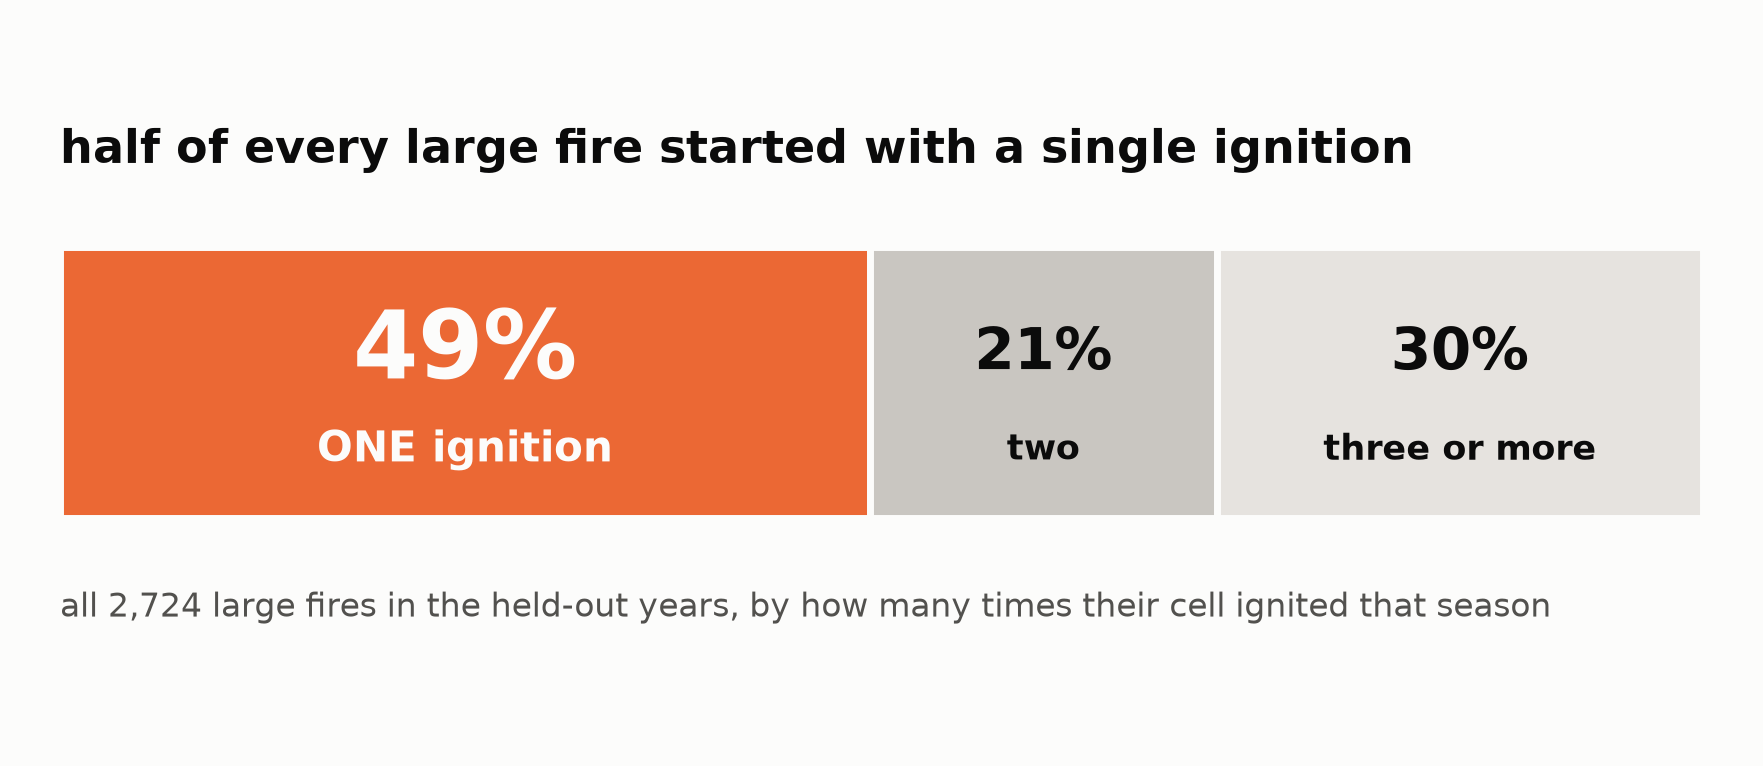

In [18]:
oe = wv.plot_one_is_enough(IMG / "w6_one_is_enough.png")
for k, v in oe.items():
    print(f"  {k:>20}: {v:.3f}" if isinstance(v, float) else f"  {k:>20}: {v}")

print("\nthe Q&A rate table, by ignition count:")
d = wv.DIAL
print(f"  {'starts':>6} {'cells':>8} {'P(big)':>8} {'per ign':>9}")
for lb, n, p, q in zip(d["labels"], d["n_cells"], d["p_big"], d["per_ign"]):
    print(f"  {lb:>6} {n:>8,} {p:>8.4f} {q:>9.4f}")

Image(filename=oe["out_path"], width=960)


**The rule is binary: does this place ignite, not how often.**

Of 2,724 held-out large-fire cells, **49.3%** had exactly one natural ignition and **70.4%** had two
or fewer. A siting rule ranked on expected ignition count would deprioritise the ground that produced
half the consequential fires.

**The counter-argument, for Q&A.** Escape probability does rise with count — 5.4% at one start to
19.1% at 11–20 — so why not rank on it? Because a twenty-fold increase in ignitions buys about 3.5x
the escape probability, and the per-ignition column falls steadily from 0.054 to 0.014. Cells that
ignite often are cells where fires get caught small: the high-ignition/low-acre regime `CLAUDE.md`
names. The rate is real; it just does not point where the fires were.

**A second reason not to build the dial.** Ignition count ranks burned area *worse* than the hex's own
burn history does — Spearman +0.253 against +0.357 — so it is neither a better acres model nor a
valid siting rule.

**What this fixes in the product.** Beat 16 alone would license "treat the hexes expected to ignite
most." Beat 17 corrects it to "treat the hexes expected to ignite **at all**," which is what
`plot_siting_glance` draws — two bands rather than graded tiers, because the finding is a threshold
and a gradient would encode a precision the data does not support.

**Scope.** JJA natural, held-out years (2010+), igniting cells only, ≥1,000 acres as "large."


## Beat 19 — the three products, closing the Tier-1 structure

The last slide, and the second in the deck that plots no data.

**Why not a chart.** The headline is three instructions, each pointing at a different product at a
different grain — a Level III cause profile, a hex ranking, a region-season triage list. Any single
figure has to pick one and demote the other two. Worse, every candidate has already been shown: the
siting map is beat 7, the triage list beat 18, the Tier-1 tiles beat 3. Re-showing one in the final
position asks the audience to re-read rather than to receive the conclusion.

**What had not been shown is all three side by side.** Drawing them that way makes the closing point
structural rather than rhetorical: the recommendation has three parts because the model has three
classes, and the deck opened on exactly that split. Beat 3 stated the allocator; this returns to it
with each class now carrying a deliverable.

**Rows are ordered by share, not by the headline's clause order.** The headline leads with cause
because that is the research question; the slide leads with Natural because that is where the acres
are, and a viewer scanning a table reads the top row as the biggest.

**It has to conclude, not specify.** An earlier version closed on *"three products, because the model
has three classes"* — true, and a description of what was built rather than a recommendation. This is
where the talk lands, so the closing line is the change being asked for: **"Stop targeting how big it
gets. Target where it starts."** That also recovers the instruction that came off beat 15's headline
when it was reframed as a grain diagnosis. The reliability caveat sits directly beneath it, because a
recommendation without its boundary is exactly what five beats of nulls exist to prevent.

Shares are the full-record Tier 1 split from `CLAUDE.md`.


   NATURAL   58.9%  hex-season
     HUMAN   22.7%  ecoregion-season
   UNKNOWN   18.5%  ecoregion-season

  shares sum to 1.001


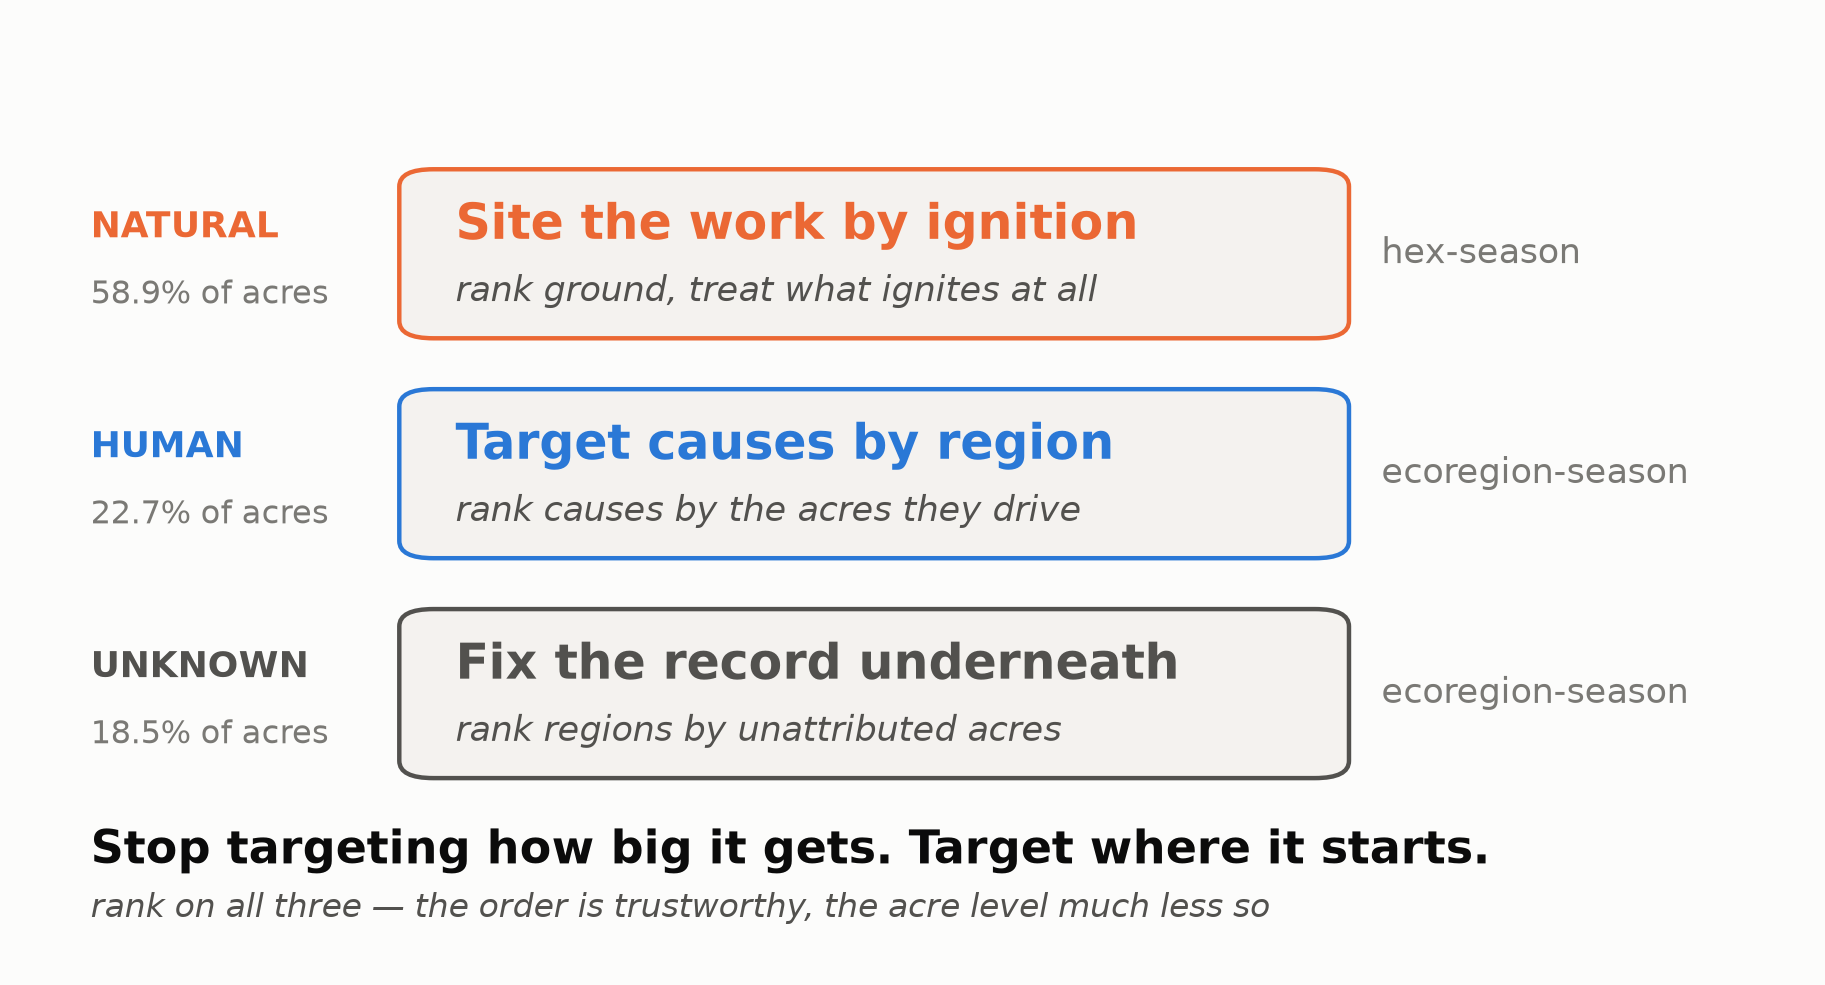

In [19]:
rec = wv.plot_recommendation(IMG / "w6_recommendation.png")
for cls, share, grain in zip(rec["classes"], rec["shares"], rec["grains"]):
    print(f"  {cls:>8}  {share:>6.1%}  {grain}")
print(f"\n  shares sum to {sum(rec['shares']):.3f}")

Image(filename=rec["out_path"], width=960)


**Stop targeting how big it gets. Target where it starts.**

That is the recommendation, and the three rows are how it decomposes — three products because the
model has three classes.

| class | share of acres | the instruction | grain |
| --- | --- | --- | --- |
| Natural | 58.9% | site the work by ignition | hex-season |
| Human | 22.7% | rank causes by the acres they drive | ecoregion-season |
| Unknown | 18.5% | fix the record underneath | ecoregion-season |

**The caveat that governs all three, and it is on the slide.** The *ranking* is the reliable part;
the acre level is not. Composing Tier 1 with the Human branch gives top-1 **0.4619** on 3,850 joined
held-out cells — identical to the Human branch scored alone, because Tier 1 contributes one scalar
that multiplies all 11 sub-shares and cannot move their argmax. The ranking therefore does not
inherit Tier 1's error. The acre level does: predicted human acres run a median 1.01x, but 2x low at
p10 and 8x high at p90.

**Two things this slide must not be read as claiming.** First, that the Human 22.7% is the true human
share — it is a **floor**, because Unknown concentrates in human-dominated regions, so the real
figure is if anything higher. Second, that siting work *reduces* the burn. Nothing in this project
measures treatment effect; the ranking says where fire is most likely to arrive, which is a necessary
condition for sited work to pay off and not a sufficient one. See `talk_notes.md` for how to answer
that question if it comes.

**What is still missing from the walkthrough.** No single worked example carries one region-season
end to end through all three products, and no prediction anywhere carries an uncertainty interval.
Both are named in `CLAUDE.md` as open.


## The mechanism behind the flat line — held for Q&A

The ladder above shows *that* the covariates added nothing. This section shows *why*, and it is the
answer to "did you actually check the data, or just fit a model that failed?"

It is deliberately **not** on the beat-12 slide. It carries a two-panel comparison across two
different x-scales, which cannot be taken in at a glance, and it argues about NDVI where the
headline is about where fires start. As a spoken answer to a question it is exactly right; as a
slide it made the audience do the inference the ladder now does for them.


## Variance decomposition

Partition NDVI's variation into between-hex and within-hex components. Year-over-year predictive
signal would require the within-hex term to be comparable to the between-hex term.

In [20]:
stats = wv.ndvi_variance_split(ndvi)
for k, v in stats.items():
    print(f"  {k:>12}: {v:,.4f}" if isinstance(v, float) else f"  {k:>12}: {v:,}")

    between_sd: 0.1323
     within_sd: 0.0478
         ratio: 2.7695
         n_hex: 2,663
       n_years: 21
         n_obs: 55,923


**Between-place spread is ~2.8x the within-hex year-to-year spread.** NDVI is predominantly a
description of location.

This is measured before any model is fit, so it is not attributable to estimator choice or tuning.

## The same decomposition, drawn

One row per hex, sorted by mean NDVI. Left: values as measured. Right: values with each hex's own mean
subtracted.

showing 150 of 2,663 hexes; between/within ratio 2.77x


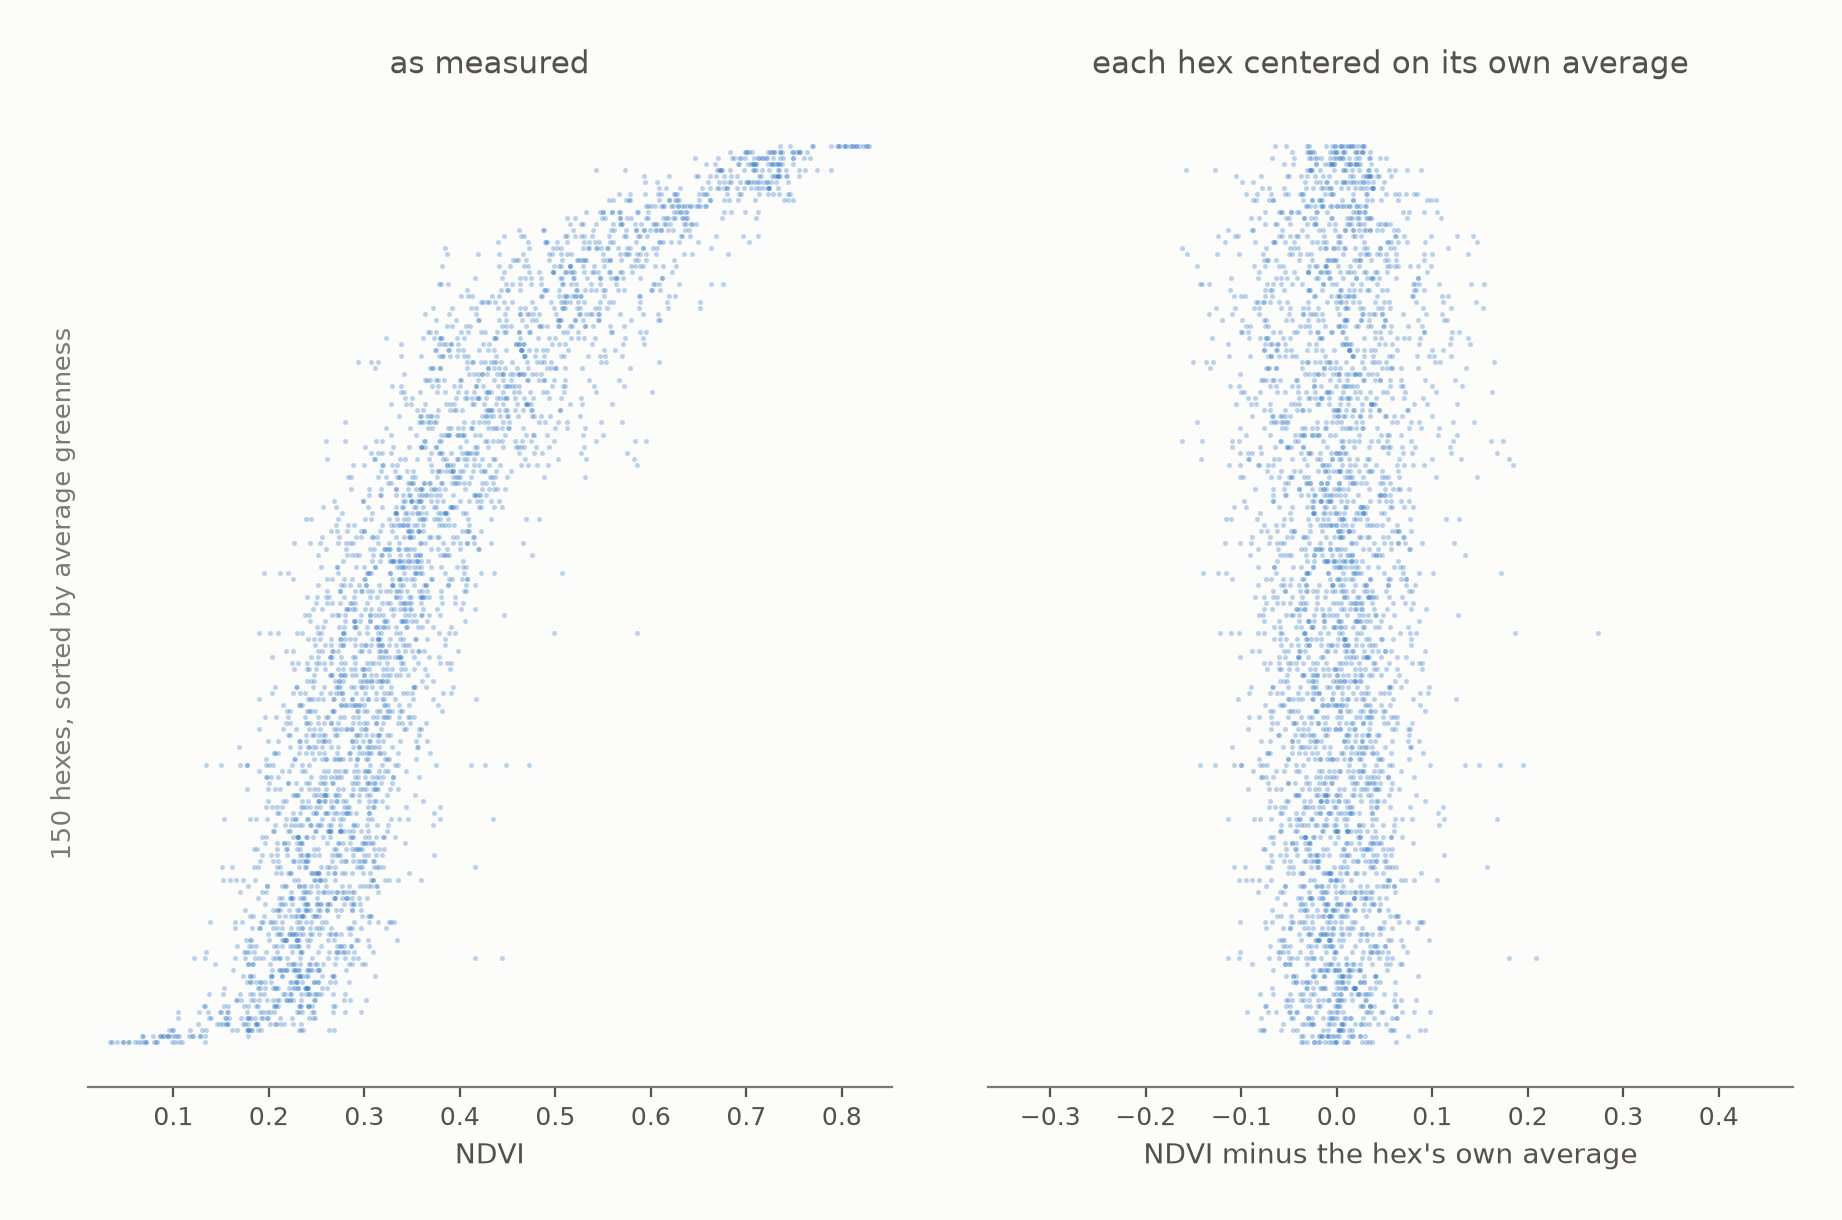

In [21]:
out = IMG / "w6_ndvi_variance.png"
info = wv.plot_ndvi_variance(ndvi, out)
print(f"showing {info['n_shown']} of {info['n_hex']:,} hexes; "
      f"between/within ratio {info['ratio']:.2f}x")

Image(filename=info["out_path"], width=980)

**The vertical structure is between-hex; centering removes nearly all of it.** Values span
0.05–0.85 across hexes and collapse to a narrow band around zero within them. The right panel is the
variation available to a covariate rung after persistence has taken the place effect.

**Scope.** JJA, 2000–2020, six forest ecoregions — the MODIS probe's coverage, and the population the
burned-area covariate gain was measured on.

## Almost all the acres are in almost none of the cells

Before looking at how well anything is forecast, establish which cells a forecast would have to get
right. Cumulative share of natural burned acres, cells ordered smallest to largest.

**Cells are ordered smallest to largest, and the next figure uses the same axis.** The two figures
are a pair, and an earlier draft ran them in opposite directions: a viewer who learned one read the
other backwards. Now the right edge means "the big burns" on both.

**Sub-acre cells stay in here, unlike the next figure.** That one drops them because their *error* is
a reporting artefact — 25.3% of FPA-FOD rows sit at exactly 0.1 acres. This figure counts *acres*,
and those acres are real however coarsely they were recorded. The cells matter enormously to the
shape and not at all to the total: **46.9% of burning cells, 0.018% of the acres**, which is
precisely the concentration the curve exists to show. Excluding them would move the headline from
98% to 93% by shrinking the count of cells rather than by removing any burn.

Zero-acre cells *are* excluded: 96% of hex-seasons never burn, and including them would make the
curve a statement about how rare fire is rather than about how it concentrates once it happens.


acres panel: loaded from hex_acres_panel.parquet
          surface: natural
        min_acres: 0.0000
        n_burning: 167768
          n_cells: 4166910
       top1_share: 0.5529
      top10_share: 0.9821
         out_path: ../img/w6_acres_concentration.png


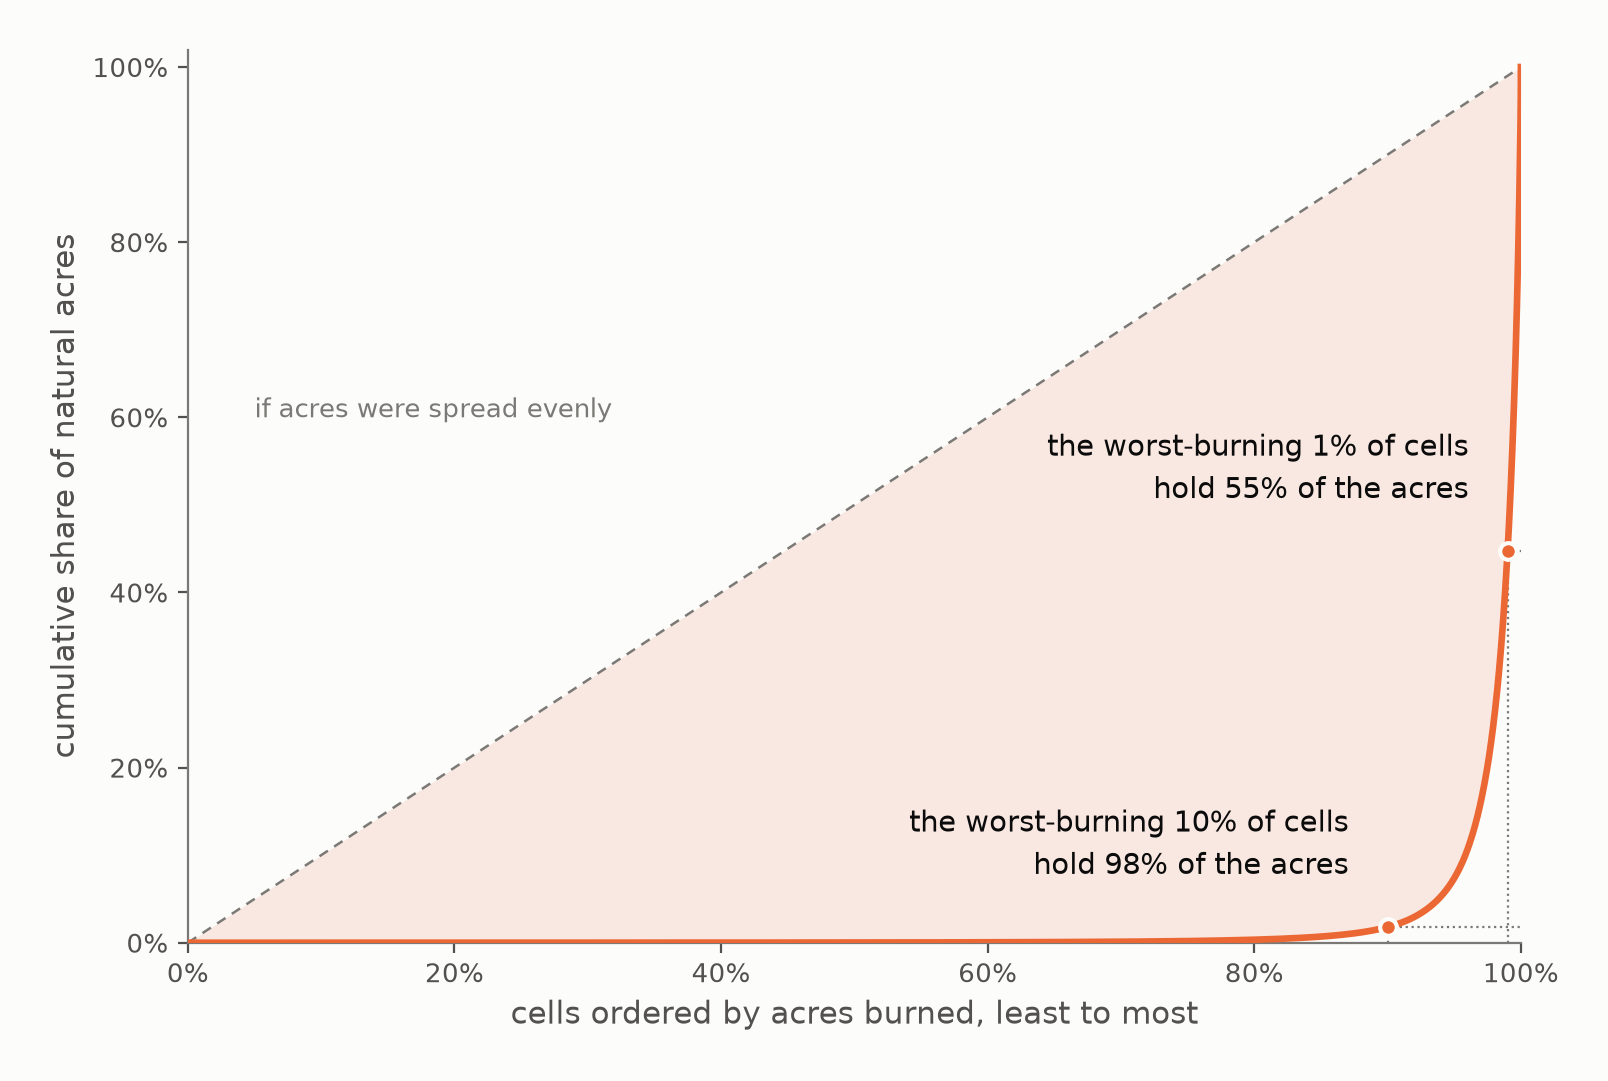

In [22]:
import hex_acres as ha

acres = ha.build_cached(DATA)

conc = wv.plot_acres_concentration(acres, IMG / "w6_acres_concentration.png")
for k, v in conc.items():
    print(f"  {k:>15}: {v:.4f}" if isinstance(v, float) else f"  {k:>15}: {v}")

Image(filename=conc["out_path"], width=820)

**The cells the forecast predicts worst are the cells that hold the acres.**

Of 167,768 burning hex-seasons, the **worst-burning 10% hold 98%** of natural acres and the
worst-burning **1% hold 55%**. The curve sits on the floor across most of the range and turns almost
vertically at the right edge. Hold that edge in mind: the next figure shows the forecast coming
apart on exactly it.

**A wording trap worth avoiding.** Every res-5 hex is the same ~62,494 acres, so "the largest 10% of
cells" reads as geography when the ordering is by *acres burned*. The figure says worst-burning, and
the axis says least to most.

That is the pair's whole argument, and the order matters. Taken alone, the next figure is a
technical result about where a baseline breaks down. Placed after this one it is consequential,
because the breakdown is not in some obscure corner of the distribution but in the part that carries
essentially all of the burn. Setting the stakes first is what turns the second slide from another
disappointment into a payoff.

**What it licenses downstream.** A product that ranks natural cells by *predicted acres* would be
ranking on the one quantity the forecast cannot supply where it matters. That is why the natural
branch ships an ignition-likelihood surface instead — the reframe beats 16–19 build on.

### A known defect in the acres surface, carried to W7

Checking the decile medians below against hex area surfaced a real problem. A res-5 hex is **62,494 acres**, so
even the worst-burning natural cells (median 8,061 acres) are only ~13% burned — but **81 cells
exceed a full hex**, the largest at 606,945 acres, or **971% of a cell**.

The cause splits two ways. The 69 perimeter-sourced cases are mostly legitimate: those fires *are*
distributed across a median of 10 hexes with weights from 0.10 to 1.0, and Alaska megafires are
simply bigger than a cell. The 23 point-sourced cases are the defect — a point-only fire puts its
entire acreage on the single hex holding its ignition, which `hex_acres` justifies at the 14-acre
average but which fails in the tail. **2,710 point fires over 1,000 acres carry 8.9% of all acres**
on that basis.

**Why the figures here stand.** Both use rank statistics — median log error by decile, cumulative
acre share — so redistributing a few thousand cells moves the top percentile's median without
changing shape, direction, or conclusion. No claim here rests on an individual cell's acreage.

**The W7 fix** is to impute a circular burn of the correct area from the ignition point and
distribute it with the same weights `hex_burn` applies to perimeters. See `CLAUDE.md` for the
geometry and the two caveats.

**Scope.** All burning cells, no acre floor (see the section intro for why this differs from the
next figure), natural surface, full record.

## Up to a point both are predictable; past that point, natural fire is harder

Typical forecast error against how much a cell burned, both branches on one log axis, **the same
axis and direction as the concentration curve above**. The statistic is the median absolute log
error read back as a multiplier. The previous figure named the right edge as the cells holding 98%
of the acres; this one shows the two branches separating on that same edge.

**Cells under 1 acre are excluded, and that is a data-quality decision rather than tidying.** 25.3%
of all FPA-FOD rows are recorded at exactly **0.1 acres** — 44.5% of natural fires against 19.0% of
human ones — which is a default entered for a fire too small to measure, not a measurement. Below
about an acre the "error" is partly the record being wrong rather than the model: dropping that
floor cuts the smallest decile's error from 10.0x to 4.3x. Removing them also flattens the
over-prediction hump that made an earlier version of this figure read as two findings instead of one.

**Populations are not interchangeable.** Natural is the all-region JJA population; the 855x figure
quoted in notebook 13 is the six-forest-ecoregion subset used for the covariate ladder. Only the
all-region figure is comparable to Human's all-region, all-season number.

                   min_acres: 1.00
               natural_top_x: 687.02
    natural_top_median_acres: 8,061.45
                 human_top_x: 18.76
      human_top_median_acres: 240.00
                   natural_n: 18633
                     human_n: 149949
                    out_path: ../img/w6_branch_deciles.png


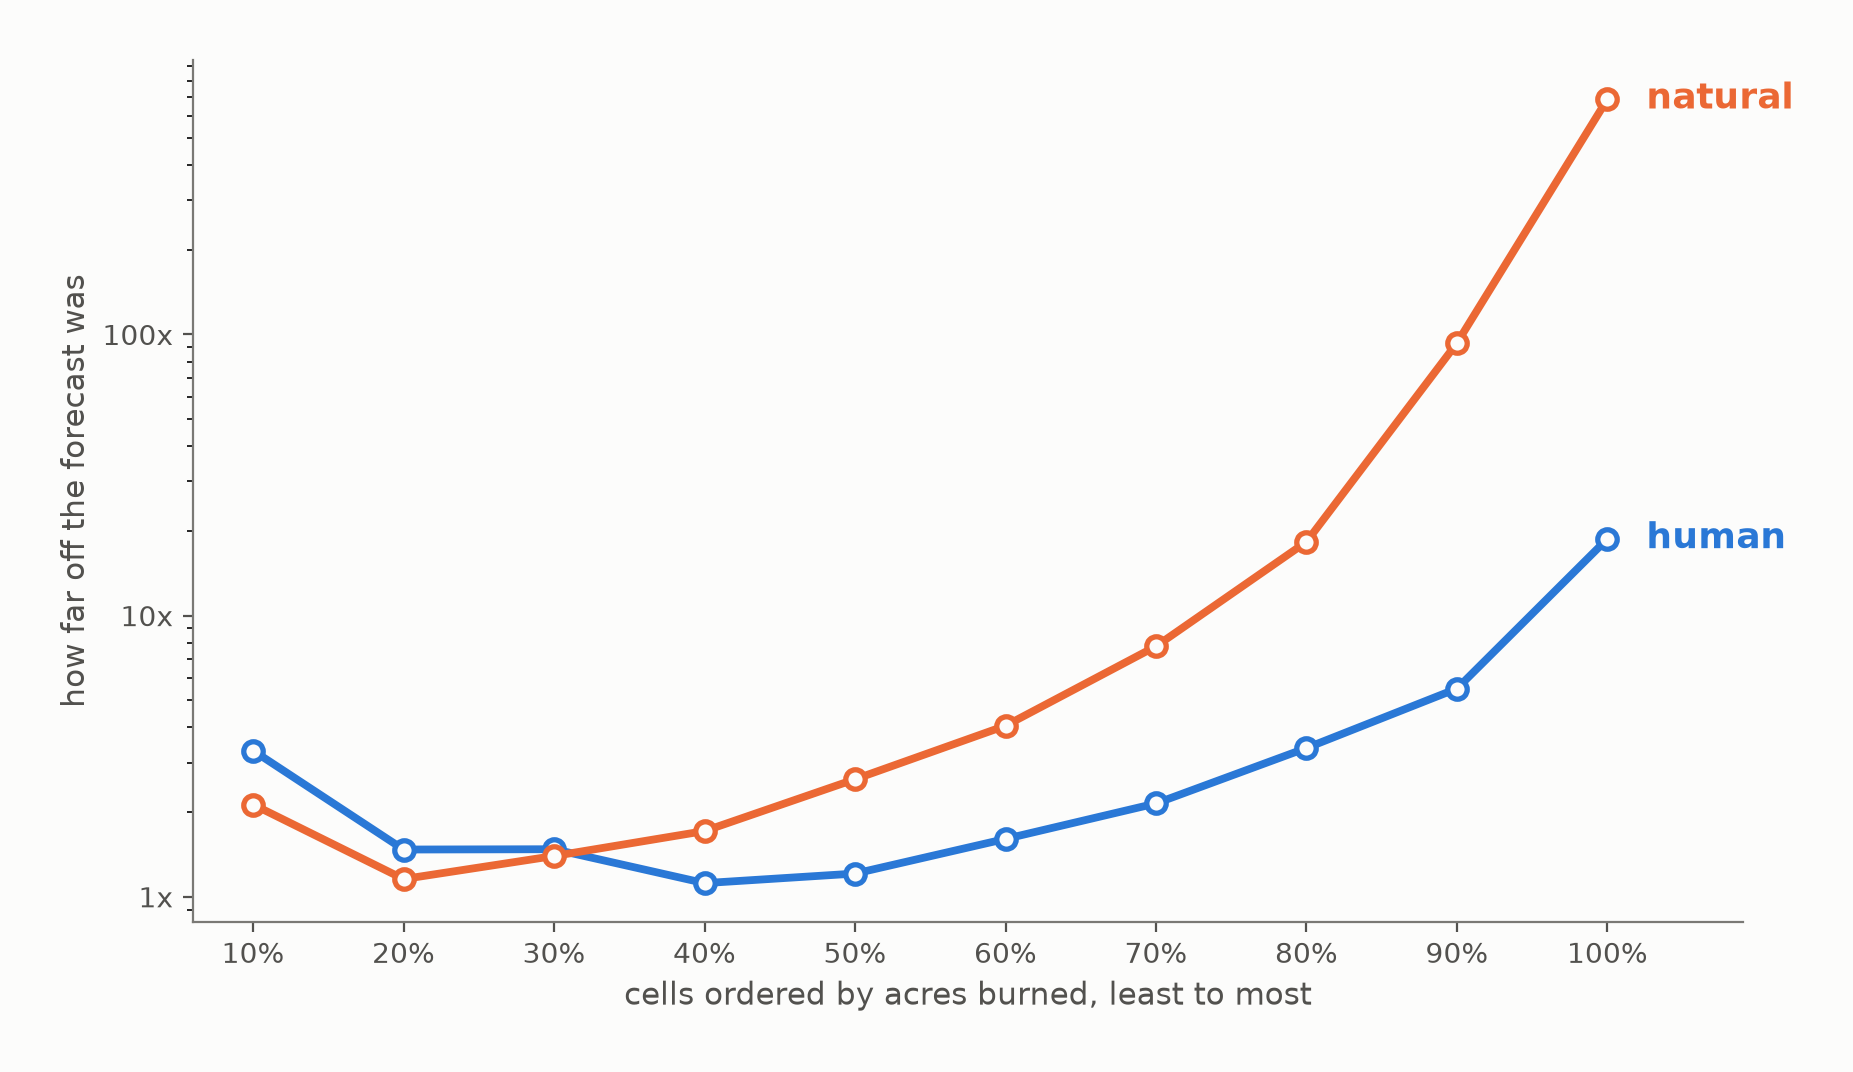

In [23]:
dec = wv.plot_branch_deciles(acres, IMG / "w6_branch_deciles.png", cfg=cfg)
for k, v in dec.items():
    print(f"  {k:>26}: {v:,.2f}" if isinstance(v, float) else f"  {k:>26}: {v}")

Image(filename=dec["out_path"], width=900)

**Up to a point both causes are predictable; past that point, natural fire is harder.**

The two curves sit on top of each other through the smallest 30% of cells and separate steadily
after. At the top the gap is an order of magnitude: **687x** on a median 8,061-acre natural cell
against **19x** on human's 240.

| position | human acres | human err | natural acres | natural err |
| --- | --- | --- | --- | --- |
| 10% | 1.0 | 4.3x | 1.0 | 4.2x |
| 30% | 2.0 | 2.9x | 3.0 | 3.9x |
| 50% | 5.0 | 2.6x | 11.1 | 5.1x |
| 70% | 12.4 | 3.0x | 60.0 | 10.5x |
| 90% | 50.0 | 5.9x | 1,005 | 93.6x |
| 100% | 240 | **19.1x** | 8,061 | **687x** |

**It is not only that natural fires get bigger.** Compare at matched cell sizes and natural is still
2–3x worse: a ~5-acre human cell is off by 2.6x against a natural cell of the same size at 4.8x; at
~12 acres it is 3.0x against 10.5x. Both effects are real — natural fire is harder to forecast *at a
given size*, and it also reaches sizes human fire does not.

**What this licenses.** Human burned area stays within about an order of magnitude even at the top,
so a human-branch product can rank cells by expected acres. Natural's tail failure is severe enough
that its product must rank by ignition likelihood instead — which is the split beat 19 acts on, and
the concentration curve above is why that failure is not survivable: the tail is the acres.

**Scope.** Held-out years, cells ≥1 acre. Human is all-season all-region (149,949 cells); natural is
JJA all-region (18,633). The two populations are not interchangeable, and the 855x figure in
notebook 13 is a third population again — the six-forest-ecoregion covariate subset.

## Caption values

In [24]:
print(f"between-place sd : {stats['between_sd']:.3f}")
print(f"within-hex sd    : {stats['within_sd']:.3f}")
print(f"ratio            : {stats['ratio']:.1f}x")
print(f"population       : {stats['n_hex']:,} hexes x {stats['n_years']} JJA seasons "
      f"= {stats['n_obs']:,} observations")

between-place sd : 0.132
within-hex sd    : 0.048
ratio            : 2.8x
population       : 2,663 hexes x 21 JJA seasons = 55,923 observations
